# **Exercicio Duelo de Modelos 4**

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:**
Selecione um dos modelos que foram explorados nos duelos de modelos ao longo do curso. Pode ser SVM, Random Forest, XGBoost, ou qualquer outro que tenhamos abordado.

**2. Aperfeiçoamento:**
**Aplique as técnicas que aprendemos para melhorar o desempenho do seu modelo:**

**Hiperparâmetros:** Utilize GridSearchCV ou RandomSearchCV para encontrar os melhores parâmetros.

**Cross Validation:** Avalie a robustez do modelo utilizando validação cruzada para garantir que ele generaliza bem.

**Balanceamento de Classes:** Se o seu modelo lida com problemas de classes desbalanceadas, explore técnicas como SMOTE, undersampling ou oversampling.

**Padronização e Normalização:** Lembre-se de padronizar os dados, especialmente se for usar modelos que são sensíveis à escala das variáveis.

**3. Submissão no Kaggle:**
Treine o seu modelo com os dados de treino e gere as previsões para os dados de teste. Lembre-se de que o conjunto de teste não possui a variável alvo (y_test), pois a avaliação será feita com base nas submissões no Kaggle.
Submeta suas previsões na competição do Titanic no Kaggle.

**4. Entrega:**
Envie o código que você desenvolveu, detalhando cada etapa do seu processo de modelagem, explicando as escolhas feitas e como essas ajudaram a melhorar o modelo.

Junto com o código, envie um print do seu score obtido na plataforma do Kaggle. Esse score será a sua métrica final de avaliação, mostrando como o seu modelo se compara com os demais.

**5. Competição Saudável:**
A ideia é trazer um senso de competição saudável, então não vale replicar exatamente o que fizemos na aula! Inove, explore novas combinações de parâmetros e técnicas, e mostre do que é capaz. O importante é exercitar o pensamento crítico e a capacidade de experimentar.

**Dicas Finais:**

Seja criativo e tenha um olhar crítico sobre o que pode ser melhorado.
Teste diferentes abordagens e não se prenda a um único caminho.
Lembre-se de que, mais do que alcançar o melhor score, o objetivo é aprender e aplicar o conhecimento de forma prática e eficaz.
Boa sorte! Estamos ansiosos para ver como cada um de vocês vai se sair nesse desafio e quais insights irão surgir dessa competição!

Ao final dessa atividade vocês terão participado da primeira competição publica de ciência de dados de vocês = )




#Importação de Bibliotecas e descrição do problema
Neste projeto, buscaremos prever a sobrevivência dos passageiros que embarcaram no Titanic, participando de uma competição na plataforma Kaggle, com base nas características descritivas de cada passageiro. A plataforma disponibiliza três arquivos: “train.csv”, “test.csv” e “gender_submission.csv”. Para resolver o problema, será utilizado o algoritmo XGBoost (XGBoost Classifier), devido à sua robustez, precisão e eficiência. Considerando os resultados obtidos em aula, surgiu a curiosidade de avaliar se seria possível obter um desempenho superior ao do SVM apresentado, comparando os modelos sob a mesma base e métricas.

In [46]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder,OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
import numpy as np
from pandas.core.indexes import category
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, cross_val_predict, RandomizedSearchCV, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import shap
from itertools import product

#Coleta e descrição dos dados
As bases de treino e teste possuem, em geral, as mesmas variáveis. A diferença é que a variável alvo (Survived) aparece apenas na base de treino.

- **PassengerId:** identificador único do registro.

- **Survived:** variável alvo booleana indicando se o passageiro sobreviveu (1) ou não (0). Presente apenas no train.csv.

- **Pclass:** variável categórica numérica indicando a classe do bilhete (1, 2, 3).

- **Name:** nome do passageiro.

- **Sex:** variável categórica indicando o sexo do passageiro.

- **Age:** variável numérica indicando a idade em anos.

- **SibSp:** variável numérica indicando a quantidade de irmãos e cônjuges a bordo.

- **Parch:** variável numérica indicando o número de pais e filhos a bordo.

- **Ticket:** identificador do bilhete (apesar de conter números em muitos casos, é uma variável categórica na prática).

- **Fare:** variável numérica indicando o valor pago pelo bilhete.

- **Cabin:** identificador da cabine (muitos valores ausentes).

- **Embarked:** porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton).

In [47]:
data_test = pd.read_csv('https://raw.githubusercontent.com/LaraPompei/Tatanic_Kaggle_Competition/refs/heads/main/test.csv')
data_train = pd.read_csv('https://raw.githubusercontent.com/LaraPompei/Tatanic_Kaggle_Competition/refs/heads/main/train.csv')

##Base de treino

In [48]:
pd.set_option('display.max_rows', None)
data_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.0708,NaN,C


In [49]:
data_train[data_train.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


##Base de teste

In [50]:
data_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.50,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.00,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.00,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.00,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.00,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.00,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.00,2,0,A/4 48871,24.1500,NaN,S


In [51]:
data_test[data_test.duplicated()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


#Exploração e limpeza dos dados

In [52]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [53]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


Iremos iniciar a exploração dos dados analisando os grupos de variáveis. Para isso, as variáveis serão classificadas em três categorias.

- As variáveis identificatórias, aquelas utilizadas apenas para individualizar cada passageiro ou registro sem adicionar informação diretamente relevante para a predição.

- As variáveis categóricas que representam atributos qualitativos e assumem um conjunto finito de categorias.

- As variáveis numéricas, as quais assumem valores quantitativos com significado direto.

- A variável objetivo do problema, por sua vez, é Survived, que indica se o passageiro sobreviveu (1) ou não (0).

In [54]:
variaveis_id = ['PassengerId', 'Name']
variaveis_categoricas = ['Pclass', 'Sex', 'Ticket', 'Cabin', 'Embarked']
variaveis_numericas = ['Age', 'Fare', 'SibSp', 'Parch']
variavel_objetivo = 'Survived'
dataset = {'Base de treino': data_train, 'Base de teste': data_test}

## Variáveis Identificatórias
Nesse grupo incluem-se as variáveis PassengerId e Name. Ambas tendem a assumir valores únicos e, por esse motivo, não agregam informação preditiva direta ao modelo, podendo inclusive induzi-lo a aprender padrões artificiais e aumentar o risco de overfitting.

Assim, inicialmente investigou-se a existência de registros duplicados com base nessas variáveis identificatórias. Em seguida, optou-se por remover a variável PassengerId da base, para evitar que ela fosse utilizada no treinamento do modelo.

Por outro lado, embora a variável Name também tenda a assumir valores únicos, ela contém o título associado ao passageiro. Essa informação pode ser relevante para identificar padrões de sobrevivência relacionados a status social, sexo ou faixa etária. Portanto, realizou-se a extração do título presente na coluna Name, de modo a preservar essa informação em uma forma mais útil para a modelagem.

In [55]:
for nome, base in dataset.items():
  print(f'Quantidade de passageiros com Id duplicada na {nome}: {base['PassengerId'].duplicated().sum()}')
  print(f'Quantidade de passageiros com Nome duplicado na {nome}: {base['Name'].duplicated().sum()}')
  print(f'Quantidade de passageiros com o nome inválido na {nome}: {base['Name'].isna().sum()}')

Quantidade de passageiros com Id duplicada na Base de treino: 0
Quantidade de passageiros com Nome duplicado na Base de treino: 0
Quantidade de passageiros com o nome inválido na Base de treino: 0
Quantidade de passageiros com Id duplicada na Base de teste: 0
Quantidade de passageiros com Nome duplicado na Base de teste: 0
Quantidade de passageiros com o nome inválido na Base de teste: 0


In [56]:
for nome, base in dataset.items():
  base['Name'] = base['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
  fig = go.Figure()
  if nome == 'Base de treino':
    sobreviventes = base.groupby(['Name', 'Survived']).size().unstack(fill_value=0).reindex(columns=[0,1], fill_value=0)
    sobreviventes['Total'] = sobreviventes[0] + sobreviventes[1]
    sobreviventes['Perc_survived'] = (sobreviventes[1]/sobreviventes['Total'])*100
    fig.add_trace(go.Bar(x=sobreviventes.index, y=sobreviventes[0], name='Did not survive', customdata=sobreviventes[['Total', 'Perc_survived']], hoverinfo='skip'))
    fig.add_trace(go.Bar(x=sobreviventes.index, y=sobreviventes[1], name='Survived', customdata=sobreviventes[['Total', 'Perc_survived']], hoverinfo='skip'))
    fig.add_trace(go.Scatter(x=sobreviventes.index, y=sobreviventes['Total'], mode='text', text=sobreviventes['Total'], textposition='top center', showlegend=False, hoverinfo='skip'))
    fig.update_layout(title=f'Frequency of titles by survival {nome}', xaxis_title='Name', yaxis_title='Frequency', barmode='stack')
  else:
    titulos = base.groupby('Name').size().sort_values(ascending=False)
    fig.add_trace(go.Bar(x=titulos.index, y=titulos.values, text=titulos.values, textposition='outside', hoverinfo='skip'))
    fig.update_layout(title=f'Frequency of titles {nome}', xaxis_title='Title', yaxis_title='Frequency')
  fig.show()
  dataset[nome]['Name'] = base['Name']

In [57]:
base = dataset['Base de treino']
dr = base[base['Name'] == 'Dr'].groupby(['Sex', 'Survived']).size().unstack().reindex()
dr['Total'] = dr[0] + dr[1]
fig = go.Figure()
fig.add_trace(go.Bar(x=dr.index, y=dr[0], name='Did not survive'))
fig.add_trace(go.Bar(x=dr.index, y=dr[1], name='Survived'))
fig.add_trace(go.Scatter(x=dr.index, y=dr['Total'], mode='text', text=dr['Total'], textposition='top center', showlegend=False, hoverinfo='skip'))
fig.update_layout(title='Survival of passengers with title Dr by gender', xaxis_title='Gender', yaxis_title='Frequency', barmode='stack')
fig.show()

Ao observar a distribuição dos títulos, é possível perceber uma grande dispersão entre as categorias. Dos 17 títulos identificados, apenas 4 apresentam frequência expressiva, enquanto os demais aparecem em número bastante reduzido. Diante disso, optou-se por reagrupar os títulos menos frequentes, de modo que passassem a compor classes maiores e mais representativas para a modelagem. Os títulos de maior frequência foram Mr (homens adultos), Mrs(Mulheres casadas), Miss(mulheres solteiras) e Master(homens jovens).

Entre os títulos de baixa incidência encontram-se Col, referência a coronel e associado a uma posição militar, Capt, referente a capitão, também um título militar, geralmente ligado à navegação, Don e Dona, títulos de nobreza comuns em países de língua espanhola, Dr, associado à profissão, Jonkheer, título de nobreza holandesa, Major, outro título militar, Mlle e Mme, formas de tratamento civis, sendo Mlle utilizada para mulheres solteiras e Mme para mulheres casadas, Ms, título feminino civil sem indicação de estado civil, Rev, associado a posição religiosa, Sir, título de nobreza, e the Countess, também relacionado à nobreza.

Como essas categorias aparecem com frequência muito baixa, sua manutenção de forma isolada poderia introduzir fragmentação excessiva na variável e dificultar a identificação de padrões pelo modelo. Por esse motivo, optou-se por reagrupar os títulos em um número menor de categorias, de modo a reduzir a esparsidade da variável e preservar a informação mais relevante que esses títulos transmitem.

Dessa forma, os títulos serão reorganizados em categorias mais amplas, de acordo com sua natureza social ou funcional, sendo elas: civis (Miss, Ms, Mrs, Mr, Mme, Mlle, Master, Dr), militares (Col, Capt, Major), religioso (Rev) e nobreza (Don, Dona, Jonkheer, Sir, the Countess).

Embora o objetivo desse reagrupamento é juntar categorias distintas e reduzir o número de categorias totais, a categoria Religioso acabou ficando com apenas um título, Rev, a sua manutenção como categoria isolada foi preservada devido ao comportamento distinto dessa classe em relação à sobrevivência, uma vez que todos os 6 passageiros identificados com esse título não sobreviveram. Dessa forma, optou-se por não reagrupar essa categoria, a fim de preservar um possível padrão preditivo.

In [58]:
titulos = {'Civil':['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Mme', 'Mlle', 'Dr'], 'Militar':['Col', 'Capt', 'Major', 'Sir'], 'Religioso':['Rev'], 'Nobreza':['Don', 'Dona', 'Jonkheer', 'Lady', 'the Countess']}
mapa = {}
for grupo, lista in titulos.items():
  for titulo in lista:
    mapa[titulo] = grupo

for nome, base in dataset.items():
  fig = go.Figure()
  dataset[nome]['Name'] = dataset[nome]['Name'].map(mapa)
  if nome == 'Base de treino':
    sobreviventes = base.groupby(['Name', 'Survived']).size().unstack(fill_value=0).reindex(columns=[0,1], fill_value=0)
    sobreviventes['Total'] = sobreviventes[0] + sobreviventes[1]
    sobreviventes['Perc_survived'] = (sobreviventes[1]/sobreviventes['Total'])*100
    fig.add_trace(go.Bar(x=sobreviventes.index, y=sobreviventes[0], name='Did not survive', customdata=sobreviventes[['Total', 'Perc_survived']]))
    fig.add_trace(go.Bar(x=sobreviventes.index, y=sobreviventes[1], name='Survived', customdata=sobreviventes[['Total', 'Perc_survived']]))
    fig.add_trace(go.Scatter(x=sobreviventes.index, y=sobreviventes['Total'], mode='text', text=sobreviventes['Total'], textposition='top center', showlegend=False, hoverinfo='skip'))
    fig.update_layout(title=f'Frequency of grouped titles by survival {nome}', xaxis_title='Group', yaxis_title='Frequency', barmode='stack')
  else:
    grupos = base.groupby('Name').size().sort_values(ascending=False)
    fig.add_trace(go.Bar(x=grupos.index, y=grupos.values, text=grupos.values, textposition='outside'))
    fig.update_layout(title=f'Frequency of grouped titles {nome}', xaxis_title='Group', yaxis_title='Frequency')
  fig.show()

In [59]:
for nome, base in dataset.items():
  dataset[nome] = base.drop(columns=variaveis_id[0])
  dataset[nome].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-nu

##Variáveis Categóricas

Esse grupo reúne variáveis de naturezas distintas. Antes de explorá-las, será necessário garantir que todas estejam com a tipagem adequada e que os valores assumidos sejam coerentes.

A variável Pclass já se encontra como inteiro, porém seus valores serão verificados para confirmar se assume apenas as classes esperadas.

As variáveis Sex e Embarked terão seus valores inspecionados com o objetivo de identificar possíveis inconsistências e, após essa checagem, serão codificadas por meio de One Hot Encoding ou Label Encoding, de modo a transformá-las em variáveis binárias compatíveis com o modelo.

Por fim, as variáveis Ticket e Cabin terão sua frequência e unicidade avaliadas para verificar se é possível extrair informações relevantes a partir de seus padrões, uma vez que, na forma bruta, apresenta alta cardinalidade e muitos valores ausentes.

In [60]:
for nome,base in dataset.items():
  print(f'base treino: {base['Pclass'].unique()}')

base treino: [3 1 2]
base treino: [3 2 1]


In [61]:
fig = make_subplots(rows=1, cols=2, subplot_titles=list(dataset.keys()))

for i, (nome, base) in enumerate(dataset.items(), start=1):
  if nome == 'Base de treino':
    sobreviventes_classe = (base.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0).sort_index()).reindex(columns=[0,1], fill_value=0)
    contagem = sobreviventes_classe.sum(axis=1)
    porcentagem = (sobreviventes_classe.div(contagem, axis=0))*100
    porcentagem_total = (contagem/contagem.sum())*100

    fig.add_trace(go.Bar(x=sobreviventes_classe.index, y=sobreviventes_classe[0], name='Não Sobreviveu', hovertext=[f"{categoria}ª classe não sobrevivente: {qtd} - {pct:.2f}%" for categoria, qtd, pct in zip(sobreviventes_classe.index, sobreviventes_classe[0].values, porcentagem[0].values)], hoverinfo='text'), row=1, col=i)
    fig.add_trace(go.Bar(x=sobreviventes_classe.index, y=sobreviventes_classe[1], name='Sobreviveu', text=[f"{c} - {p:.2f}%" for c, p in zip(contagem.values, porcentagem_total.values)], textposition='outside', hovertext=[f"{categoria}ª classe sobrevivente: {qtd} - {pct:.2f}%" for categoria, qtd, pct in zip(sobreviventes_classe.index, sobreviventes_classe[1].values, porcentagem[1].values)], hoverinfo='text'), row=1, col=i)

  else:
    contagem = base['Pclass'].value_counts().sort_index()
    porcentagem = (contagem/contagem.sum())*100
    fig.add_trace(go.Bar(x=contagem.index, y=contagem.values, text=[f"{c} - {p:.2f}%" for c, p in zip(contagem.values, porcentagem.values)], textposition='outside', hovertext=[f"{categoria}ª classe: {qtd} - {pct:.2f}%" for categoria, qtd, pct in zip(contagem.index, contagem.values, porcentagem.values)], hoverinfo='text'), row=1, col=i)

  fig.update_layout(title='Distribuição de passageiros por classe', barmode='stack', showlegend=False)
  fig.update_xaxes(title_text='Classe', tickmode='linear', dtick=1, row=1, col=i)
  fig.update_yaxes(title_text='Frequência', row=1, col=i)

fig.show()

Em ambas as bases de treino e teste, a variável Pclass apresenta valores coerentes com o esperado, assumindo apenas as classes previstas. Portanto, não foi necessária nenhuma modificação nessa variável.

Além disso, a partir da análise do histograma, observou-se um desbalanceamento na frequência de registros entre as classes 1ª, 2ª e 3ª, com comportamento bastante semelhante entre treino e teste.

Em ambas as bases, a maior incidência é a 3ª classe, representando aproximadamente 55% na base de treino e 52% na base de teste. Em seguida, a 1ª classe aparece como a segunda mais frequente, com cerca de 24% na base de treino e 26% na base de teste. Por fim, a 2ª classe apresenta a menor incidência, porém com valores próximos aos da 1ª classe, correspondendo a aproximadamente 21% na base de treino e 22% na base de teste.

Ao analisar a taxa de sobrevivência por classe na base de treino, observa-se que a maior proporção de sobreviventes está concentrada na 1ª classe, na qual aproximadamente 63% dos passageiros sobreviveram. Em seguida, encontra-se a 2ª classe, com taxa de sobrevivência próxima de 48%. Já a 3ª classe, embora apresente em números absolutos mais sobreviventes do que a 2ª, devido à sua maior quantidade de passageiros, foi a que registrou a menor probabilidade de sobrevivência em termos proporcionais, com aproximadamente 24% dos passageiros sobrevivendo.

In [62]:
for nome,base in dataset.items():
  print(f'{nome}: \nGênero:{base['Sex'].unique()}\nLocal de embarque:{base['Embarked'].unique()}')

Base de treino: 
Gênero:['male' 'female']
Local de embarque:['S' 'C' 'Q' nan]
Base de teste: 
Gênero:['male' 'female']
Local de embarque:['Q' 'S' 'C']


Ao analisar os valores únicos das colunas 'Sex' e 'Embarked' em ambas as bases, constatou-se a presença de valores ausentes (NaN) na coluna 'Embarked' da base de treino. Como o modelo não conseguiria processar esses valores de forma direta, optou-se por imputar os dois registros com valor ausente utilizando a categoria mais frequente da própria coluna, preservando o tamanho amostral e mantendo a consistência das categorias utilizadas no treinamento.

In [63]:
print('Dados nan da base de treino:\n', dataset['Base de treino'][dataset['Base de treino']['Embarked'].isna()])
dataset['Base de treino']['Embarked'] = dataset['Base de treino']['Embarked'].fillna(dataset['Base de treino']['Embarked'].mode()[0])
print('Dados nan tratados da base de treino:\n', dataset['Base de treino'].loc[[61,829]])

Dados nan da base de treino:
      Survived  Pclass   Name     Sex   Age  SibSp  Parch  Ticket  Fare Cabin  \
61          1       1  Civil  female  38.0      0      0  113572  80.0   B28   
829         1       1  Civil  female  62.0      0      0  113572  80.0   B28   

    Embarked  
61       NaN  
829      NaN  
Dados nan tratados da base de treino:
      Survived  Pclass   Name     Sex   Age  SibSp  Parch  Ticket  Fare Cabin  \
61          1       1  Civil  female  38.0      0      0  113572  80.0   B28   
829         1       1  Civil  female  62.0      0      0  113572  80.0   B28   

    Embarked  
61         S  
829        S  


In [64]:
colunas = ['Sex','Embarked']
mask = {'Sex':'Gênero', 'Embarked':'Local de Embarque'}
trad = {'male':'homem', 'female':'mulher'}

for col in colunas:
  contagem = {}
  porcentagem = {}
  fig = make_subplots(rows=1, cols=2, subplot_titles=list(dataset.keys()))
  for i, (nome, base) in enumerate(dataset.items(), start=1):
    if nome == 'Base de treino':
      sobreviventes_classe = base.groupby([col,'Survived']).size().unstack(fill_value=0).sort_index()
      sobreviventes_classe = sobreviventes_classe.reindex(columns=[0,1], fill_value=0)
      contagem = sobreviventes_classe.sum(axis=1)
      porcentagem = (sobreviventes_classe.div(contagem, axis=0))*100
      porcentagem_total = (contagem/contagem.sum())*100

      rotulo = sobreviventes_classe.index if col != 'Sex' else [trad.get(c, str(c)) for c in sobreviventes_classe.index]

      fig.add_trace(go.Bar(x=sobreviventes_classe.index, y=sobreviventes_classe[0], name='Não Sobreviveu', hovertext=[f"{r} não sobrevivente: {qtd} - {pct:.2f}%" for r, qtd, pct in zip(rotulo, sobreviventes_classe[0].values, porcentagem[0].values)], hoverinfo='text'), row=1, col=i)
      fig.add_trace(go.Bar(x=sobreviventes_classe.index, y=sobreviventes_classe[1], name='Sobreviveu', text=[f"{c} - {p:.2f}%" for c, p in zip(contagem.values, porcentagem_total.values)], textposition='outside', hovertext=[f"{r} sobrevivente: {qtd} - {pct:.2f}%" for r, qtd, pct in zip(rotulo, sobreviventes_classe[1].values, porcentagem[1].values)], hoverinfo='text'), row=1, col=i)

    else:
      contagem[nome] = base[col].value_counts().sort_index()
      porcentagem[nome] = (contagem[nome]/contagem[nome].sum())*100
      fig.add_trace(go.Bar(x=contagem[nome].index, y=contagem[nome].values, text=[f"{c} - {p:.2f}%" for c, p in zip(contagem[nome].values, porcentagem[nome].values)], textposition='outside', hovertext=[f"{categoria} Total: {qtd} - {pct:.2f}%" for categoria, qtd, pct in zip(contagem[nome].index, contagem[nome].values, porcentagem[nome].values)], hoverinfo='text'), row=1, col=i)

    fig.update_layout(title=f'Distribuição de {mask[col]}', barmode='stack', showlegend=False)
    fig.update_yaxes(title_text='Frequência', row=1, col=i)

  fig.show()

Ao analisar a distribuição das variáveis Gênero (Sex) e Local de Embarque (Embarked), é possível afirmar que, assim como ocorre para a variável de classe (Pclass), as bases de treino e teste apresentam proporções semelhantes entre suas categorias.

Em relação ao gênero, observa-se um desbalanceamento em ambas as bases, com a incidência de passageiros masculinos sendo quase o dobro da incidência de passageiros femininos.

Quanto ao local de embarque, o padrão também se mantém, com Southampton (Inglaterra) como categoria mais frequente, representando 72,5% dos embarques na base de treino e 64,6% na base de teste. Em seguida, Cherbourg (França) corresponde a 18,9% dos embarques na base de treino e 24,4% na base de teste. Por fim, Queenstown (Irlanda) é o local menos frequente, com 8,64% na base de treino e 11% na base de teste.

Para aprofundar a compreensão do conjunto de dados, torna-se relevante avaliar a incidência dessas variáveis em conjunto, analisando a proporção dos grupos quando cruzados. Essa abordagem permite responder questões como: qual a proporção de passageiros de cada gênero por classe, se existia um local de embarque mais frequente em cada classe, e se havia algum local de embarque majoritário por gênero.

In [65]:
plots = [
  {'titulo':'Classe por local de embarque (%)','x':'Embarked','stack':'Pclass','x_label':'Local de embarque','stack_prefix':'Pclass ','ordem_x':sorted(dataset['Base de treino']['Embarked'].unique()),'ordem_stack':sorted(dataset['Base de treino']['Pclass'].unique())},
  {'titulo':'Gênero por local de embarque (%)','x':'Embarked','stack':'Sex','x_label':'Local de embarque','stack_prefix':'','ordem_x':sorted(dataset['Base de treino']['Embarked'].unique()),'ordem_stack':sorted(dataset['Base de treino']['Sex'].unique())},
  {'titulo':'Gênero por classe (%)','x':'Pclass','stack':'Sex','x_label':'Classe','stack_prefix':'','ordem_x':sorted(dataset['Base de treino']['Pclass'].unique()),'ordem_stack':sorted(dataset['Base de treino']['Sex'].unique())}
]

for p in plots:
  contagem = {}
  porcentagem = {}
  fig = make_subplots(rows=1, cols=2, subplot_titles=list(dataset.keys()))

  for i, (nome, base) in enumerate(dataset.items(), start=1):
    contagem[nome] = base.groupby([p['x'], p['stack']]).size().unstack(fill_value=0).reindex(index=p['ordem_x'], columns=p['ordem_stack'], fill_value=0)
    porcentagem[nome] = contagem[nome].div(contagem[nome].sum(axis=1).replace(0, 1), axis=0)*100

    for v in p['ordem_stack']:
      fig.add_trace(go.Bar(x=p['ordem_x'], y=porcentagem[nome][v].values, text=[f"{c} - {pct:.2f}%" for pct, c in zip(porcentagem[nome][v].values, contagem[nome][v].values)], textposition='inside', textfont=dict(color='white'), name=f"{p['stack_prefix']}{v}"), row=1, col=i)

    fig.update_xaxes(title_text=p['x_label'], type='category', row=1, col=i)
    fig.update_yaxes(title_text='Percentual', row=1, col=i)

  fig.update_layout(title=p['titulo'], barmode='stack')
  fig.show()

Respondendo à primeira pergunta, sobre a proporção de passageiros de cada classe por local de embarque, observa-se que, na base de treino, Southampton foi o porto mais comum para passageiros de todas as classes. Nesse local, 55% dos embarques correspondem à 3ª classe, 25% à 2ª classe e 20% à 1ª classe. Considerando que a 3ª classe concentra 372 não sobreviventes, quase metade de toda a base de treino, é possível compreender por que Southampton apresenta uma incidência tão elevada de não sobreviventes quando comparado aos outros dois portos.

Embora esse padrão de embarque para cada classe se mantenha na base de teste, nota-se uma diferença relevante na 1ª classe. Nessa base, a maior parte dos passageiros da 1ª classe embarcou em Cherbourg, enquanto as demais classes continuaram concentradas majoritariamente em Southampton. Essa diferença sugere que a relação entre classe e local de embarque não se repete de forma idêntica entre treino e teste, o que exige atenção na interpretação dessa variável durante a modelagem, pois o modelo pode aprender padrões da base de treino que não se reproduzem integralmente na base de teste.

Como tendência geral, aproximadamente metade dos embarques realizados em Cherbourg corresponde a passageiros da 1ª classe, com 51% na base de treino e 55% na base de teste. Esse comportamento também ajuda a explicar a maior incidência de sobreviventes entre os passageiros embarcados nesse porto, considerando que a 1ª classe apresentou a maior taxa de sobrevivência do conjunto.

Já em Queenstown, os embarques foram predominantemente compostos por passageiros da 3ª classe, representando 93% na base de treino e 89% na base de teste. No entanto, apesar dessa forte concentração de passageiros da 3ª classe, Queenstown apresentou uma taxa de sobrevivência superior à de Southampton. Esse resultado pode indicar a existência de padrões adicionais que merecem investigação. Entre as hipóteses possíveis, pode-se considerar a presença majoritária de um gênero específico entre os embarcados nesse porto, ou ainda a possibilidade de esses passageiros terem sido alocados em regiões do navio associadas a maior probabilidade de sobrevivência.

A 2ª classe, por sua vez, manteve um comportamento bastante consistente entre as duas bases, com maior concentração de embarques em Southampton, formando o segundo maior grupo nesse local. Em seguida, Cherbourg aparece como o segundo porto com maior incidência de passageiros da 2ª classe. Por fim, em Queenstown, embora o volume de passageiros da 2ª classe seja reduzido, sua incidência ainda permanece superior à da 1ª classe.

Na análise do local de embarque por gênero, não se observa um padrão tão evidente quanto o identificado entre local de embarque e classe, o que sugere uma associação mais fraca entre as variáveis Sex e Embarked. De forma geral, a maior parte dos embarques em todos os locais foi realizada por passageiros do gênero masculino, o que é coerente com a maior presença de homens na base de dados. Ainda assim, na maior parte dos pontos de embarque as proporções entre os gêneros não se mostraram tão distantes.

A maior discrepância ocorreu em Southampton, na base de treino, onde 68% dos passageiros embarcados eram do gênero masculino e 32% do gênero feminino. Na base de teste, o comportamento foi muito semelhante, com 67% de passageiros masculinos e 33% femininos. Além disso, para ambos os gêneros, o local mais frequente de embarque foi Southampton, seguido por Cherbourg e, por último, Queenstown.

Por fim, Queenstown o local de embarque em que a incidência feminina mais aproximou, e em um dos casos até superou, a masculina. Na base de teste, as mulheres representaram 52% dos embarques nesse porto, tornando-o o único local com predominância feminina. Esse comportamento também pode ser observado na base de treino, embora em menor intensidade, já que a proporção de mulheres embarcando em Queenstown ainda se mantém elevada e bastante próxima à de homens.Esse comportamento reforça uma das hipóteses levantadas anteriormente para explicar o porquê desse porto, apesar de apresentar alta incidência de passageiros da 3ª classe, possuir uma taxa de sobrevivência superior à observada em Southampton, onde o embarque é majoritariamente masculino, correspondendo a aproximadamente 68% dos passageiros.

Na análise do último conjunto de histogramas, que relaciona gênero por classe, observa-se que, em todas as classes, a presença de homens é superior à presença de mulheres. A classe com proporções mais equilibradas é a 1ª classe em ambas as bases, porém na base de treino, as mulheres representam 43% e os homens 56%, enquanto na base de teste essa diferença se reduz, com 47% de mulheres e 53% de homens.

Em relação ao desbalanceamento, a 3ª classe apresenta a maior discrepância de gênero na base de treino. Já na base de teste, a maior diferença ocorre na 2ª classe, embora as proporções entre 2ª e 3ª classes sejam relativamente próximas nessa base.

Ao generalizar o comportamento de distribuição de passageiros por cada classe, é possível afirmar que a maior quantidade de homens e mulheres está concentrada na 3ª classe em ambas as bases, o que reflete a maior representatividade dessa classe no conjunto de dados. Ao observar a distribuição dentro de cada gênero, nota-se que, tanto na base de treino quanto na de teste, a maior incidência de mulheres ocorre na 3ª classe, seguida pela 1ª e, por último, a 2ª. Para os homens, o comportamento na base de treino segue o mesmo padrão (3ª, 1ª, 2ª). Já na base de teste, a ordem se altera para 3ª, 2ª e 1ª classe.

A próxima análise das variáveis categóricas concentrou-se nas colunas que provavelmente exigirão maiores modificações, 'Ticket' e 'Cabin', pois não são diretamente numéricas e apresentam alta cardinalidade.

Inicialmente, verificou-se a existência de valores ausentes (NaN) ou nulos. Constatou-se que, em ambas as bases, a variável 'Ticket' não apresentou anomalias desse tipo. Em contrapartida, a variável 'Cabin' demonstrou alta incidência de valores ausentes, indicando a necessidade de um tratamento específico antes da etapa de modelagem.

In [66]:
ticket_vazio = {}
cabine_vazia = {}
for nome, base in dataset.items():
  print(nome)
  ticket_vazio[nome] = base['Ticket'].isna().sum()
  cabine_vazia[nome] = base['Cabin'].isna().sum()
  print(f'Quantidade de registros vazios na coluna "Ticket": {ticket_vazio}/{base.shape[0]}')
  print(f'Quantidade de registros vazios na coluna "Cabin": {cabine_vazia}/{base.shape[0]}')

Base de treino
Quantidade de registros vazios na coluna "Ticket": {'Base de treino': np.int64(0)}/891
Quantidade de registros vazios na coluna "Cabin": {'Base de treino': np.int64(687)}/891
Base de teste
Quantidade de registros vazios na coluna "Ticket": {'Base de treino': np.int64(0), 'Base de teste': np.int64(0)}/418
Quantidade de registros vazios na coluna "Cabin": {'Base de treino': np.int64(687), 'Base de teste': np.int64(327)}/418


Para definir o melhor curso de ação, foi necessário avaliar se a ausência de valores na coluna Cabin seguia algum padrão. Para isso, formulou-se a hipótese de que os registros faltantes poderiam estar associados à 3ª classe, considerando a possibilidade de existir uma modalidade de bilhete em que o passageiro não possuísse uma cabine individual registrada.

Assim, inicialmente investigou-se se os valores ausentes em Cabin estavam concentrados em alguma classe de bilhete específica. Em seguida, analisou-se a incidência desses passageiros entre sobreviventes e não sobreviventes, com o objetivo de compreender se a ausência dessa informação poderia estar relacionada à taxa de sobrevivência e, consequentemente, qual seria sua relevância para a etapa de modelagem.

In [67]:
classe = {}
sobrevivente = {}
for nome,base in dataset.items():
  classe[nome] = base[base['Cabin'].isna()]['Pclass'].value_counts()
  sobrevivente[nome] = base[base['Cabin'].isna()].groupby('Pclass')['Survived'].sum() if nome == "Base de treino" else 0
  print(f'{nome}')
  print(f"Quantidade de valores de cabine vazio em cada classe:\n{classe[nome]}")
  print(f"Quantidade de valores de cabine vazio em cada classe e sua sobrevivencia:\n{sobrevivente[nome]}")
  print(f'Porcentagem de sobreviventes sem cabine registrada por classe: \n {100*(sobrevivente[nome]/classe[nome])}')
  if nome == 'Base de treino':
    print(f"Na {nome}, constatou-se uma concentração de {100*(classe[nome][3]/cabine_vazia[nome]):.2f}% dos valores faltantes de 'Cabin' em bilhetes da 3ª classe, onde apenas {100*(sobrevivente[nome][3]/classe[nome][3]):.2f}% sobreviveram, \n{100*(classe[nome][2]/cabine_vazia[nome]):.2f}% em bilhetes da 2ª classe, onde {100*(sobrevivente[nome][2]/classe[nome][2]):.2f}% sobreviveram, e {100*(classe[nome][1]/cabine_vazia[nome]):.2f}% em bilhetes da 1ª classe, onde {100*(sobrevivente[nome][1]/classe[nome][1]):.2f}% sobreviveram.")
  else:
    print(f"Um comportamento semelhante foi identificado na base de teste, onde {100*(classe[nome][3]/cabine_vazia[nome]):.2f}% dos valores faltantes estavam em passageiros da 3ª classe, {100*(classe[nome][2]/cabine_vazia[nome]):.2f}% em passageiros da 2ª classe e apenas {100*(classe[nome][1]/cabine_vazia[nome]):.2f}% em passageiros da 1ª classe.")

Base de treino
Quantidade de valores de cabine vazio em cada classe:
Pclass
3    479
2    168
1     40
Name: count, dtype: int64
Quantidade de valores de cabine vazio em cada classe e sua sobrevivencia:
Pclass
1     19
2     74
3    113
Name: Survived, dtype: int64
Porcentagem de sobreviventes sem cabine registrada por classe: 
 Pclass
1    47.500000
2    44.047619
3    23.590814
dtype: float64
Na Base de treino, constatou-se uma concentração de 69.72% dos valores faltantes de 'Cabin' em bilhetes da 3ª classe, onde apenas 23.59% sobreviveram, 
24.45% em bilhetes da 2ª classe, onde 44.05% sobreviveram, e 5.82% em bilhetes da 1ª classe, onde 47.50% sobreviveram.
Base de teste
Quantidade de valores de cabine vazio em cada classe:
Pclass
3    214
2     86
1     27
Name: count, dtype: int64
Quantidade de valores de cabine vazio em cada classe e sua sobrevivencia:
0
Porcentagem de sobreviventes sem cabine registrada por classe: 
 Pclass
3    0.0
2    0.0
1    0.0
Name: count, dtype: float64


In [68]:
for nome, base in dataset.items():
  total = base['Pclass'].value_counts().sort_index()
  for c in base['Pclass'].unique():
    print(f"Na {nome}, constatou-se uma concentração de {100*(classe[nome][c]/total[c]):.2f}% dos valores de 'Cabin' são faltantes em bilhetes da {c}a classe")

Na Base de treino, constatou-se uma concentração de 97.56% dos valores de 'Cabin' são faltantes em bilhetes da 3a classe
Na Base de treino, constatou-se uma concentração de 18.52% dos valores de 'Cabin' são faltantes em bilhetes da 1a classe
Na Base de treino, constatou-se uma concentração de 91.30% dos valores de 'Cabin' são faltantes em bilhetes da 2a classe
Na Base de teste, constatou-se uma concentração de 98.17% dos valores de 'Cabin' são faltantes em bilhetes da 3a classe
Na Base de teste, constatou-se uma concentração de 92.47% dos valores de 'Cabin' são faltantes em bilhetes da 2a classe
Na Base de teste, constatou-se uma concentração de 25.23% dos valores de 'Cabin' são faltantes em bilhetes da 1a classe


Com relação a taxa de sobrevivência, é possível dizer que metade das pessoas da primeira e segunda classe que não possuiam cabines registradas sobreviveram o titanic, porém esse valor é alterado para 23% quando se trata da terceira classe. Essa proporção se mostra bastante semelhante à taxa de sobrevivência observada por classe de forma geral, havendo apenas uma leve redução entre os sobreviventes da 1ª classe. Esse comportamento indica que a ausência de registro de cabine, isoladamente, talvez não exerça influência tão significativa sobre a sobrevivência.

Ao verificar as proporções de passageiros em cada classe, observou-se que, embora a hipótese inicial de que a ausência de valores em 'Cabin' esteja relacionada à 3ª classe possa estar correta, devido a sua incidência maior dentre o grupo de dados faltantes, ela não é suficiente para explicar completamente todos os registros vazios.

Portanto, criou-se uma hipótese adicional que será investigada na parte de pré-processamento dos dados, para avaliar a possibilidade de que parte desses passageiros não possuísse a cabine registrada por compartilharem o mesmo 'Ticket' com outro(s) passageiro(s) cuja cabine estivesse identificada.

Porém como essa análise depende da formatação da variável Ticket e da criação de uma nova variável, ela será realizada na etapa de pré-processamento e no momento, a coluna cabin terá seus valores inválidos preenchidos com 'Unknown'.

In [69]:
for nome, base in dataset.items():
  base['Cabin'] = base['Cabin'].fillna('Unknown')
  print(f'Quantidade de registros vazios na coluna "Cabin" no {nome}: {base['Cabin'].isna().sum()}/{base.shape[0]}')


Quantidade de registros vazios na coluna "Cabin" no Base de treino: 0/891
Quantidade de registros vazios na coluna "Cabin" no Base de teste: 0/418


Para a variável Ticket, não foram identificados valores preenchidos de forma inválida. Dessa forma, nesta etapa será realizada apenas a padronização dos registros, garantindo que a variável não seja sensível a maiúsculas e minúsculas e que não contenha espaços extras. Em seguida, será avaliada a distribuição e a frequência dos valores para verificar a existência de padrões, em especial a formação de grupos de passageiros associados ao mesmo ticket, o que pode indicar viagens em conjunto e permitir a extração de atributos mais informativos.


In [70]:
for nome, base in dataset.items():
  dataset[nome]['Ticket'] = base['Ticket'].astype(str).str.upper().str.strip().str.replace(' ', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '', regex=False).str.replace('/', '', regex=False)
  total_passengers = len(base)

  numTickets = base['Ticket'].value_counts()
  TicketsSize = numTickets.value_counts().sort_index()
  RegisterGroup = (TicketsSize.index * TicketsSize.values)

  ticketGroups = dict(zip(TicketsSize.index, TicketsSize))

  for size, num in ticketGroups.items():
    print(f"Total de registros com Ticket em grupo {size} na {nome}: {num}/{total_passengers} ({num/total_passengers:.2%})")

Total de registros com Ticket em grupo 1 na Base de treino: 547/891 (61.39%)
Total de registros com Ticket em grupo 2 na Base de treino: 94/891 (10.55%)
Total de registros com Ticket em grupo 3 na Base de treino: 21/891 (2.36%)
Total de registros com Ticket em grupo 4 na Base de treino: 11/891 (1.23%)
Total de registros com Ticket em grupo 5 na Base de treino: 2/891 (0.22%)
Total de registros com Ticket em grupo 6 na Base de treino: 3/891 (0.34%)
Total de registros com Ticket em grupo 7 na Base de treino: 3/891 (0.34%)
Total de registros com Ticket em grupo 1 na Base de teste: 321/418 (76.79%)
Total de registros com Ticket em grupo 2 na Base de teste: 33/418 (7.89%)
Total de registros com Ticket em grupo 3 na Base de teste: 6/418 (1.44%)
Total de registros com Ticket em grupo 4 na Base de teste: 2/418 (0.48%)
Total de registros com Ticket em grupo 5 na Base de teste: 1/418 (0.24%)


Com base na análise da concentração de passageiros em cada grupo de ticket, observa se que a maioria, 61,39%, viajou ou adquiriu o bilhete de forma individual. À medida que o tamanho do grupo aumenta, a quantidade de registros associados a esse mesmo ticket diminui, indicando que compras em grupos maiores foram menos frequentes.

As bases de treino e teste apresentaram comportamento bastante semelhante. Ao comparar a incidência de gênero em cada categoria de grupo de viagem, observa se que homens são mais frequentes na maior parte dos grupos. Nos casos em que a participação feminina se iguala ou supera a masculina, a distribuição tende a ficar muito próxima de um equilíbrio entre 50% e 50%. Esse resultado é consistente com a predominância de homens no conjunto de dados.

Ao avaliar a distribuição de classes por tamanho de grupo de ticket, nota se que, em todas as classes, a compra individual é a mais comum. Entretanto, para grupos muito grandes (maiores que 5), não foram encontrados registros associados às classes 1 e 2, concentrando se apenas na terceira classe.

Por fim, ao analisar a sobrevivência por tamanho de grupo, observa se um indício de maior probabilidade de sobrevivência entre passageiros que viajaram em dupla.


##Variáveis Numéricas
Esse grupo é composto por variáveis que representam quantidades, como idade (Age), quantidade de irmãos e cônjuges a bordo (SibSp), quantidade de pais e filhos a bordo (Parch) e o valor pago pela passagem (Fare). Antes de explorá las, será verificada a presença de valores ausentes (NaN) e de valores inválidos, como números negativos em variáveis nas quais esse tipo de valor não faz sentido. Além disso, será conferida a tipagem de cada coluna, garantindo que o tipo de dado esteja adequado ao conteúdo que ela representa.

In [71]:
for tipo, base in dataset.items():
  totCol = len(base)
  for col in variaveis_numericas:
    numNan = base[col].isna().sum()
    numNeg = (base[col]<0).sum()
    print(f"A coluna {col} da {tipo} apresenta {numNan} ({100*(numNan/totCol):.2f}%) valores inválidos e {numNeg} valores negativos de um total de {totCol}")
  print('\n')

A coluna Age da Base de treino apresenta 177 (19.87%) valores inválidos e 0 valores negativos de um total de 891
A coluna Fare da Base de treino apresenta 0 (0.00%) valores inválidos e 0 valores negativos de um total de 891
A coluna SibSp da Base de treino apresenta 0 (0.00%) valores inválidos e 0 valores negativos de um total de 891
A coluna Parch da Base de treino apresenta 0 (0.00%) valores inválidos e 0 valores negativos de um total de 891


A coluna Age da Base de teste apresenta 86 (20.57%) valores inválidos e 0 valores negativos de um total de 418
A coluna Fare da Base de teste apresenta 1 (0.24%) valores inválidos e 0 valores negativos de um total de 418
A coluna SibSp da Base de teste apresenta 0 (0.00%) valores inválidos e 0 valores negativos de um total de 418
A coluna Parch da Base de teste apresenta 0 (0.00%) valores inválidos e 0 valores negativos de um total de 418




A partir da análise realizada, foi possível identificar que aproximadamente 20% dos registros da variável Age em ambas as bases apresentam valores ausentes. Para tratar esses registros e evitar viés, optou se pela imputação dos valores faltantes com base na mediana, priorizando a mediana calculada por grupo (Pclass e Sex). Nos casos em que não houve grupo correspondente, foi utilizada como critério de preenchimento a mediana global calculada na base de treino.

In [72]:
for nome, base in dataset.items():
  dataset[nome]['Age'] = base['Age'].fillna(base.groupby(['Pclass','Sex'])['Age'].transform('median'))
  dataset[nome]['Fare'] = base['Fare'].fillna(base.groupby(['Pclass','Sex'])['Fare'].transform('median'))
  print(f"Total de nans na {nome} na coluna 'Age': {dataset[nome]['Age'].isna().sum()}\n",
      f"Total de nans na {nome} na coluna 'Fare': {dataset[nome]['Fare'].isna().sum()}\n")

Total de nans na Base de treino na coluna 'Age': 0
 Total de nans na Base de treino na coluna 'Fare': 0

Total de nans na Base de teste na coluna 'Age': 0
 Total de nans na Base de teste na coluna 'Fare': 0



Após resolver os valores inválidos, vamos tratar o tipo da variável Age que foi armazenada como float64, embora, por se tratar de idade em anos, o tipo inteiro seja mais apropriado para representar essa informação. Em contrapartida, as variáveis SibSp e Parch, que quantificam o número de irmãos e cônjuges, bem como pais e filhos a bordo, estão corretamente representadas como inteiros. Por fim, a variável Fare, que indica o valor pago pela passagem, também apresenta tipagem adequada ao ser armazenada como float64, uma vez que pode assumir valores com casas decimais.

In [73]:
for nome, base in dataset.items():
  dataset[nome]['Age'] = dataset[nome]['Age'].astype('int64')

In [74]:
variaveis_numericas

['Age', 'Fare', 'SibSp', 'Parch']

Após tratar os dados faltantes, vamos analisar as distribuições das variáveis numéricas.

In [75]:

titles = ['Distribuição de idade nos registros do titanic', 'Distribuição de valor de passagem do titanic', 'Distribuição de irmão/conjuge a bordo do titanic', 'Distribuição de pais/filhos a bordo do titanic']

for nome, base in dataset.items():
  figure = make_subplots(rows = 2, cols = 2, subplot_titles=titles)

  for i,col in enumerate(variaveis_numericas):
    r = (i // 2) + 1
    c = (i % 2) + 1
    if r%2 == 0:
      figure.add_trace(go.Histogram(x=base[col], name=col, showlegend=False), row=r, col=c)
    else:
      figure.add_trace(go.Box(y=base[col], name=col, boxpoints='outliers', showlegend=False), row=r, col=c)

    figure.update_yaxes(title_text=col, row=r, col=c)
    figure.update_xaxes(title_text=col, row=r, col=c)

  figure.update_layout(height=750, width=1100, title_text=f'Ditribuição das variáveis numéricas na {nome}')
  figure.show()


Com base nos boxplots realizados, é possível perceber a presença de muitos outliers em idade e preço de passagem. Como se trata do Titanic e existem classes diferentes, e considerando que, na exploração dos dados, observou-se que o valor da passagem varia consideravelmente de acordo com a classe, será feito um novo conjunto de boxplots para as variáveis Age e Fare, estratificando por taxa de sobrevivência e por gênero dentro de cada classe.

In [76]:
titles = ['Boxplot de idade por classe e gênero', 'Boxplot de valor da passagem por classe e gênero']
for nome, base in dataset.items():
  if nome == 'Base de treino':
    for sobrevivencia, rotulo in zip([0,1], ['Não sobreviventes', 'Sobreviventes']):
      figure = make_subplots(rows=1, cols=2, subplot_titles=titles)
      filtro = base['Survived'] == sobrevivencia
      for i, col in enumerate(['Age','Fare']):
        r = (i // 2) + 1
        c = (i % 2) + 1
        for sexo in base['Sex'].dropna().unique():
          mask = (base['Sex'] == sexo) & filtro
          figure.add_trace(go.Box(x=base.loc[mask,'Pclass'], y=base.loc[mask,col], name=sexo, legendgroup=sexo, boxpoints='outliers', showlegend=(i == 0)), row=r, col=c)
        figure.update_xaxes(title_text='Pclass', categoryorder='array', categoryarray=[1,2,3], row=r, col=c)
        figure.update_yaxes(title_text=col, row=r, col=c)
      figure.update_layout(height=600, width=1100, title_text=f'Boxplots de Age e Fare por classe e gênero entre {rotulo} na {nome}', boxmode='group')
      figure.show()
  else:
    figure = make_subplots(rows=1, cols=2, subplot_titles=titles)
    for i, col in enumerate(['Age','Fare']):
      r = (i // 2) + 1
      c = (i % 2) + 1
      for sexo in base['Sex'].dropna().unique():
        mask = base['Sex'] == sexo
        figure.add_trace(go.Box(x=base.loc[mask,'Pclass'], y=base.loc[mask,col], name=sexo, legendgroup=sexo, boxpoints='outliers', showlegend=(i == 0)), row=r, col=c)
      figure.update_xaxes(title_text='Pclass', categoryorder='array', categoryarray=[1,2,3], row=r, col=c)
      figure.update_yaxes(title_text=col, row=r, col=c)
    figure.update_layout(height=600, width=1100, title_text=f'Boxplots de Age e Fare por classe e gênero na {nome}', boxmode='group')
    figure.show()

Mesmo após a separação das variáveis Idade e Tarifa por classe, gênero e taxa de sobrevivência, é possível notar uma quantidade considerável de outliers. Ainda assim, esses valores não parecem inconsistentes com a realidade da base, já que as idades observadas continuam dentro de faixas plausíveis e as tarifas, embora bastante dispersas, são compatíveis com diferenças de classe, acomodação e possíveis particularidades associadas ao bilhete.

Ao observar apenas a variável idade, nota-se que a 1ª classe tende a concentrar passageiros com medianas de idade mais elevadas, enquanto a 3ª classe reúne grupos relativamente mais jovens. Esse padrão aparece tanto na base de teste quanto na base de treino, inclusive quando os passageiros são separados entre sobreviventes e não sobreviventes. Entre os sobreviventes, chama atenção a presença de idades mais baixas, especialmente entre homens da 2ª e da 3ª classes, o que pode sugerir maior sobrevivência entre passageiros masculinos mais jovens. Já entre os não sobreviventes, as distribuições masculinas permanecem mais dispersas, com forte concentração de homens na 3ª classe e medianas intermediárias ou mais baixas nas classes inferiores.

Em relação à variável Fare, a diferença entre as classes é notória. A 1ª classe apresenta medianas muito superiores às demais e também concentra a maior dispersão, além dos outliers mais altos de toda a base. As 2ª e 3ª classes, por outro lado, exibem distribuições mais comprimidas e valores centrais substancialmente menores. Isso reforça que a tarifa é uma variável fortemente associada à classe do bilhete.

Quando a tarifa é observada em conjunto com gênero e sobrevivência, surgem padrões ainda mais relevantes. Entre os sobreviventes, especialmente na 1ª classe, as mulheres apresentam distribuição de tarifas elevada e relativamente concentrada em faixas altas, já entre os homens há maior dispersão. Entre os não sobreviventes, a concentração masculina é mais evidente, sobretudo nas classes inferiores, e os valores de tarifa tendem a ser menores. Esse comportamento sugere que tarifa, classe e gênero interagem entre si e podem estar relacionadas à probabilidade de sobrevivência, embora parte desse efeito provavelmente reflita o próprio peso da classe social na dinâmica do naufrágio.

Também vale destacar que os maiores valores de tarifa aparecem quase exclusivamente na 1ª classe, tanto na base de treino quanto na de teste. Isso indica que os outliers de Fare não devem ser tratados automaticamente como erros, mas sim como possíveis observações reais de passageiros com acomodações de alto custo ou bilhetes com características específicas.

In [77]:
portos = ['C','Q','S']
nomes_portos = {'C':'Cherbourg', 'Q':'Queenstown', 'S':'Southampton'}
sexos = ['female','male']
nomes_sexos = {'female':'Feminino', 'male':'Masculino'}
classes = [1,2,3]

titles = []
for porto in portos:
  for sexo in sexos:
    titles.append(f'{nomes_portos[porto]} - {nomes_sexos[sexo]}')

for nome, base in dataset.items():
  figure = make_subplots(rows=3, cols=6, subplot_titles=titles*3)

  for i, classe in enumerate(classes):
    r = i + 1
    for j, porto in enumerate(portos):
      for k, sexo in enumerate(sexos):
        c = (j * 2) + k + 1
        mask = (base['Pclass'] == classe) & (base['Embarked'] == porto) & (base['Sex'] == sexo)
        figure.add_trace(go.Box(y=base.loc[mask,'Fare'], name=nomes_sexos[sexo], boxpoints='outliers', showlegend=False), row=r, col=c)
        figure.update_yaxes(title_text='Fare', row=r, col=c)

  figure.update_layout(height=1000, width=1800, title_text=f'Boxplots da tarifa por classe, local de embarque e gênero na {nome}')
  figure.add_annotation(text='1ª classe', xref='paper', yref='paper', x=-0.03, y=1.05, showarrow=False)
  figure.add_annotation(text='2ª classe', xref='paper', yref='paper', x=-0.03, y=0.65, showarrow=False)
  figure.add_annotation(text='3ª classe', xref='paper', yref='paper', x=-0.03, y=0.25, showarrow=False)
  figure.show()

Ao observar os últimos gráficos gerados, nota-se uma redução da incidência de outliers quando a tarifa é analisada de forma mais segmentada por classe, gênero e local de embarque. Esse comportamento sugere que parte da dispersão observada anteriormente não estava associada apenas à variável tarifa (Fare) de forma isolada, mas também às diferenças existentes entre os portos, as classes e o perfil dos passageiros. A partir dessa nova visualização, torna-se possível tirar conclusões mais específicas sobre o comportamento das tarifas.

Com relação aos passageiros da 1ª classe, Southampton foi o porto com maior incidência de embarques. Na base de treino, os homens embarcados nesse porto apresentaram mediana de tarifa em torno de 35, com grande dispersão dos valores, variando aproximadamente entre 0 e 100 e com outliers que alcançam valores próximos de 263. Já entre as mulheres, o comportamento se mostrou mais concentrado, com mediana mais alta, em torno de 79, variação entre aproximadamente 25 e 211 e presença de um outlier também próximo de 263. Na base de teste, observa-se comportamento semelhante. Os homens apresentaram mediana em torno de 42, ligeiramente superior à observada na base de treino, com menor incidência de outliers, embora ainda com valores elevados, atingindo cerca de 221. As mulheres, por sua vez, mantiveram mediana superior à masculina, porém inferior à observada na base de treino, com mediana próxima de 61, valor mínimo em torno de 25 e máximo próximo de 263.

O segundo porto com maior incidência de embarques na 1ª classe foi Cherbourg, que, como observado anteriormente, concentrou proporcionalmente mais passageiros dessa classe do que os demais portos. Nesse local, os homens da 1ª classe apresentaram, na base de treino, mediana de tarifa próxima de 61, com variação entre aproximadamente 26 e 211 e poucos outliers, embora um deles atinja valor muito elevado, em torno de 512. As mulheres embarcadas em Cherbourg exibiram comportamento semelhante, porém com mediana ainda mais alta, próxima de 83, variando entre cerca de 27 e 227, também com poucos outliers e valores extremos semelhantes aos observados entre os homens. Na base de teste, esse comportamento se altera um pouco. Os homens apresentam mediana próxima de 73, com valores entre aproximadamente 25 e 262 e sem presença relevante de outliers. Já as mulheres apresentam mediana em torno de 81, com variação entre aproximadamente 27 e 262 e presença de um único outlier extremo no valor de 512.

Em Queenstown, o número de embarques da 1ª classe foi muito reduzido, o que limita a interpretação do boxplot. Nesse caso, a baixa quantidade de observações impede conclusões mais robustas sobre o comportamento da tarifa nesse grupo.

De forma geral, para a 1ª classe, é possível afirmar que Southampton apresentou a maior variabilidade nas tarifas pagas por passageiros de ambos os gêneros. Além disso, as mulheres tenderam a apresentar medianas superiores às dos homens, enquanto os homens, em contrapartida, mostraram maior dispersão nos valores pagos.

Para os passageiros da 2ª classe, o comportamento foi um pouco diferente. Assim como na 1ª classe, Southampton foi o porto com maior frequência de embarques. Na base de treino, os homens da 2ª classe embarcados nesse porto apresentaram mediana de tarifa em torno de 13, com valor mínimo próximo de 10, máximo em torno de 32 e presença de outliers acima de 60. As mulheres apresentaram mediana em torno de 24, valor mínimo próximo de 10 e máximo em torno de 39. Já na base de teste, os homens mantiveram mediana semelhante, próxima de 13, com variação entre aproximadamente 0 e 39 e um outlier em torno de 73,5. As mulheres, por sua vez, apresentaram mediana próxima de 23 e variação entre aproximadamente 10 e 39, com um outlier próximo de 65. De forma geral, tanto na base de treino quanto na de teste, as mulheres da 2ª classe embarcadas em Southampton apresentaram medianas superiores às dos homens.

Em Cherbourg, os passageiros da 2ª classe apresentaram distribuição mais equilibrada entre os gêneros. Na base de treino, homens e mulheres exibiram medianas bastante próximas, em torno de 25 e 24, respectivamente, com variação semelhante entre aproximadamente 12 e 41. Na base de teste, o comportamento se altera. Os homens apresentam mediana mais baixa, próxima de 15, enquanto as mulheres apresentam mediana mais alta, próxima de 32. Nesse caso, a diferença entre os gêneros torna-se mais evidente, fazendo da 2ª classe em Cherbourg um dos grupos com maior discrepância entre os valores pagos por homens e mulheres.

Em Queenstown, novamente há poucos embarques da 2ª classe, o que reduz a capacidade interpretativa do gráfico. Ainda assim, é possível notar que os valores pagos nesse porto tendem a se manter abaixo das medianas observadas nos outros dois portos.

Já a 3ª classe foi a que apresentou maior variação no comportamento das tarifas entre os diferentes grupos. Em Southampton, que concentra o maior número de embarques dessa classe, os homens da base de treino pagaram valores entre aproximadamente 6 e 69, com distribuição bastante dispersa, o que torna a mediana pouco representativa do conjunto. As mulheres apresentaram comportamento mais definido, com mediana próxima de 14, valor mínimo em torno de 7, máximo em torno de 47 e presença de um outlier próximo de 69. Esse padrão se mantém de forma semelhante na base de teste. Os homens continuam apresentando valores bastante dispersos, entre aproximadamente 3 e 69, enquanto as mulheres mantêm distribuição mais concentrada, com valores entre aproximadamente 7 e 25, mediana próxima de 12 e alguns outliers adicionais, incluindo valores também próximos de 69.

Em Cherbourg, o comportamento das tarifas da 3ª classe é mais organizado. Na base de treino, os homens apresentam mediana próxima de 7 e valores concentrados em uma faixa baixa, embora ainda exista presença de outliers, com valores em torno de 14, 15 e acima de 20. As mulheres apresentam distribuição mais padronizada, com mediana próxima de 14, mínimo em torno de 6 e máximo em torno de 22. Na base de teste, os homens também exibem comportamento mais estável, com mediana em torno de 7, mínimo próximo de 6 e máximo em torno de 22. Já as mulheres apresentam mediana próxima de 11, mínimo em torno de 7 e máximo em torno de 15. Nesse grupo, os homens permanecem mais concentrados em valores inferiores aos pagos pelas mulheres.

Por fim, em Queenstown, a baixa quantidade de passageiros dificulta a interpretação do boxplot da 3ª classe. Ainda assim, é possível notar que, na base de teste, a maior parte dos embarcantes pagou menos de 10 pela passagem. Na base de treino, os homens parecem ter pago majoritariamente valores abaixo de 15, enquanto as mulheres se concentram em valores abaixo de 10.

De forma geral, a análise segmentada da tarifa por classe, gênero e local de embarque mostra que a variável Fare é fortemente influenciada principalmente pela classe do passageiro, mas também sofre impacto relevante do porto de embarque e, em alguns casos, do gênero. Além disso, parte dos outliers observados anteriormente deixa de parecer tão anômala quando a base é dividida em subgrupos mais homogêneos, indicando que muitos desses valores extremos podem refletir diferenças estruturais reais entre os perfis de passageiros, e não necessariamente inconsistências nos dados.

In [78]:
titles = ['Histograma de irmãos/conjuge por classe e gênero', 'Histograma de pais/filhos por classe e gênero']

for nome, base in dataset.items():
  figure = make_subplots(rows=1, cols=2, subplot_titles=titles)

  for i, col in enumerate(['SibSp','Parch']):
    r = (i // 2) + 1
    c = (i % 2) + 1
    for pclasse in sorted(base['Pclass'].unique()):
      for sexo in base['Sex'].unique():
        mask = (base['Pclass'] == pclasse) & (base['Sex'] == sexo)
        figure.add_trace(go.Histogram(x=base.loc[mask, col], name=f'Classe {pclasse} | {sexo}', legendgroup=f'{pclasse}_{sexo}', showlegend=(i == 0), xbins=dict(size=1)), row=r, col=c)
    figure.update_xaxes(title_text=col, row=r, col=c)
    figure.update_yaxes(title_text='Count', row=r, col=c)

  figure.update_layout(height=600, width=1100, title_text=f'Histogramas de SibSp e Parch por classe e gênero na {nome}', barmode='overlay')
  figure.show()

##Variável Objetivo
Por último, analisaremos a distribuição dos sobreviventes, nossa variável objetivo, para verificar se ela é equilibrada ou se sua distribuição é desigual entre as classes dessa variável.

In [79]:
sobreviventes = data_train['Survived'].value_counts().sort_index().reset_index()
sobreviventes.columns=['Sobrevivência', 'Total de passageiros']
figure = px.bar(sobreviventes, x='Sobrevivência', y='Total de passageiros', title='Distribuição dos sobreviventes na base de treino')
figure.update_xaxes(type='category', tickvals=[0,1], ticktext=['Não sobreviveu', 'Sobreviveu'])
figure.show()
print(f'O total de sobreviventes do titanic da base de treino correponde a {(sobreviventes.loc[sobreviventes['Sobrevivência'] == 1, 'Total de passageiros'].sum() / sobreviventes['Total de passageiros'].sum()) * 100:.2f}%')

O total de sobreviventes do titanic da base de treino correponde a 38.38%


Com base no gráfico, podemos perceber que a quantidade de pessoas da base de dados que não sobreviveram ao acidente é de 549, equivalente a aproximadamente 62% da amostra, enquanto os sobreviventes correspondem a cerca de 38%. Isso indica que a variável objetivo está desbalanceada. Embora o modelo escolhido seja menos sensível a esse tipo de desbalanceamento, iremos aplicar SMOTE na etapa de pré-processamento para balancear as classes e reduzir o risco de o modelo priorizar a classe majoritária e perder desempenho na identificação da classe minoritária.

#Pré-processamento dos dados
Nessa etapa, será realizada a transformação das variáveis já limpas em um conjunto de features apropriadas para a modelagem. Iniciaremos convertendo as variáveis categóricas para formatos numéricos, de modo que possam ser utilizadas pelos algoritmos de machine learning. Em seguida, aplicaremos feature engineering sempre que uma coluna puder ser desmembrada ou recombinada, de acordo com a relevância da informação extraída. Por último, a variável objetivo será tratada considerando o desbalanceamento identificado entre suas classes, de forma a reduzir o viés para a classe majoritária.

Por fim, será plotada e analisada a matriz de correlação, com o intuito de identificar relações lineares relevantes entre as features.

##Variável Identificatória
A única variável identificatória restante é a Name, que agora armazena os títulos de cada passageiro, que foram extraídos e reagrupados na seção anterior. Dessa forma, a variável deixa de funcionar como um identificador único e passa a representar uma informação categórica potencialmente relevante para a modelagem, já que os grupos de títulos apresentaram comportamentos distintos em relação à sobrevivência.

Contudo, para que essa informação possa ser utilizada pelo modelo, essa coluna precisará ser codificada. Para isso, será aplicado o One Hot Encoding, transformando cada categoria em uma variável binária. A categoria Civil, por concentrar a maior parte das observações e apresentar menor relevância preditiva, será adotada como grupo de referência e removida após a codificação, evitando redundância entre as variáveis geradas.

Devido a raridade das classes com exceção a civil, a utilidade preditiva dessas novas variáveis será avaliada por meio da comparação entre modelos com e sem a inclusão dos grupos derivados de Name, permitindo verificar se essa informação realmente contribui para o desempenho da modelagem ou não.

In [80]:
for nome, base in dataset.items():
  print(base['Name'].unique())
  print(f"Dados originais de classe social na {nome}:\n{base['Name'].value_counts()}\n")
  encoder = OneHotEncoder(sparse_output=False)
  one_hot_encoded = encoder.fit_transform(base[['Name']])

  colunas_codificadas = encoder.get_feature_names_out(['Name'])
  df_codificado = pd.DataFrame(one_hot_encoded, columns=colunas_codificadas, index=base.index)

  dataset[nome] = pd.concat([base.drop(columns=['Name']), df_codificado], axis=1)
  print(dataset[nome].head(0))

['Civil' 'Nobreza' 'Religioso' 'Militar']
Dados originais de classe social na Base de treino:
Name
Civil        875
Religioso      6
Militar        6
Nobreza        4
Name: count, dtype: int64

Empty DataFrame
Columns: [Survived, Pclass, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked, Name_Civil, Name_Militar, Name_Nobreza, Name_Religioso]
Index: []
['Civil' 'Militar' 'Religioso' 'Nobreza']
Dados originais de classe social na Base de teste:
Name
Civil        413
Militar        2
Religioso      2
Nobreza        1
Name: count, dtype: int64

Empty DataFrame
Columns: [Pclass, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked, Name_Civil, Name_Militar, Name_Nobreza, Name_Religioso]
Index: []


##Variáveis categóricas

Iniciaremos nosso modelo tratando as variáveis Ticket e Cabin, que apontaram maior necessidade de tratamento. A variável Ticket será utilizada para gerar uma nova variável chamada Group, que indicará, para cada registro, o tamanho do grupo que comprou a passagem em conjunto.

Já a variável Cabin será utilizada para gerar três novas variáveis. A primeira será Has_Cabin, como se trata de uma coluna muito esparsa, essa variável indicará apenas se o passageiro possuía ou não uma cabine no navio. A segunda será Qtd_Cabins, já que foram observados alguns casos em que mais de uma cabine estava associada a um mesmo ticket. Percebeu-se que, na maior parte dos casos, as cabines compradas em grupo pertenciam à mesma ala, com exceção de alguns registros em que apareciam cabines dos tipos F e E acompanhadas de numeração. Como nesses casos não ficou claro qual cabine foi efetivamente utilizada pela pessoa, decidiu-se manter essa informação para verificar se ela possui algum impacto relevante na sobrevivência. Por fim, também foi criada a variável ALA, que corresponde ao primeiro caractere da coluna Cabin.

In [81]:
for nome, base in dataset.items():
  dataset[nome]['Group'] = base.groupby('Ticket')['Ticket'].transform('count')
  dataset[nome]['Has_cabin'] = (base['Cabin'] != 'Unknown').astype(bool)
  dataset[nome]['Qtd_cabins'] = base['Cabin'].apply(lambda cabin: 0 if cabin == 'Unknown' else len(cabin.split()))
  dataset[nome]['Ala'] = base['Cabin'].apply(lambda cabin: 'U' if cabin == 'Unknown' else 'M' if len(set([cabine[0] for cabine in cabin.split()])) > 1 else cabin[0])
  dataset[nome]['Sozinho'] = base['Group'].apply(lambda group: 1 if group == 1 else 0).astype(bool)

  print(dataset[nome]['Has_cabin'].value_counts())
  print(dataset[nome]['Sozinho'].value_counts())
  print(dataset[nome]['Group'].value_counts())
  print(dataset[nome]['Qtd_cabins'].value_counts())
  print(dataset[nome]['Ala'].unique())

  print(f'\nDistribuição de Qtd_cabins por Grupo na {nome}:\n')
  print(pd.crosstab(base['Qtd_cabins'], base['Group']))

  print(f'\nDistribuição de Gênero por Grupo na {nome}:\n')
  print(pd.crosstab(base['Sex'], base['Group']))

  dataset[nome] = base.drop(columns=['Cabin', 'Ticket'])

Has_cabin
False    687
True     204
Name: count, dtype: int64
Sozinho
True     547
False    344
Name: count, dtype: int64
Group
1    547
2    188
3     63
4     44
7     21
6     18
5     10
Name: count, dtype: int64
Qtd_cabins
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64
['U' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'M' 'T']

Distribuição de Qtd_cabins por Grupo na Base de treino:

Group         1    2   3   4   5   6   7
Qtd_cabins                              
0           458  117  35  28  10  18  21
1            84   65  27   4   0   0   0
2             4    4   0   8   0   0   0
3             1    0   1   4   0   0   0
4             0    2   0   0   0   0   0

Distribuição de Gênero por Grupo na Base de treino:

Group     1    2   3   4  5   6   7
Sex                                
female  134  102  36  27  1   6   8
male    413   86  27  17  9  12  13
Has_cabin
False    327
True      91
Name: count, dtype: int64
Sozinho
True     321
False     97
Name: count, dtype: 

Após a etapa de limpeza e engenharia de variáveis nas colunas Cabin e Ticket, seguiu-se para a fase de codificação das variáveis. As variáveis categóricas, que assumem valores não numéricos, foram codificadas utilizando o LabelEncoder.

In [82]:
ordem_ala = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'M', 'T', 'U']
ordem_classe = [1, 2, 3]

for nome, base in dataset.items():
  tabela = pd.crosstab(base['Ala'], base['Pclass']).reindex(ordem_ala).fillna(0)
  porcentagem = tabela.div(tabela.sum(axis=1), axis=0).fillna(0) * 100

  fig = go.Figure()

  for classe in ordem_classe:
    y = tabela[classe] if classe in tabela.columns else pd.Series(0, index=tabela.index)
    texto = porcentagem[classe].apply(lambda x: f'{x:.1f}%' if x > 0 else '') if classe in porcentagem.columns else [''] * len(tabela.index)

    fig.add_bar(x=tabela.index, y=y, name=str(classe), text=texto, textposition='inside')

  fig.update_layout(title=f'Distribuição de Ala por Classe - {nome}', barmode='stack', xaxis_title='Ala', yaxis_title='Quantidade', legend_title='Classe')
  fig.show()

É possível observar que a maior parte dos passageiros não possui cabine registrada e que, entre esses casos, predomina a 3ª classe. Além disso, tanto na 3ª quanto na 2ª classe, a maioria dos passageiros não apresenta um valor definido para cabine. No entanto, a 3ª classe possui apenas 12 passageiros com cabine registrada, o que representa cerca de 2,5% do total de passageiros dessa classe na base de treino. Já a 2ª classe apresenta 16 passageiros com cabine registrada e, como o número total de passageiros dessa classe é consideravelmente menor que o da 3ª, esse valor corresponde a aproximadamente 9,5% do total de passageiros da 2ª classe.

Entre os passageiros da 3ª classe com cabine registrada, observa-se na base de treino maior incidência nas alas G, M, E e F, nessa ordem. Na base de teste, esses passageiros aparecem apenas nas alas M e G. Já os passageiros da 2ª classe com cabine registrada concentram-se nas alas F, D e E, na base de treino, e F e D, na base de teste.

O comportamento da 1ª classe é diferente. Embora também existam passageiros sem cabine registrada, essa ausência é proporcionalmente menor quando comparada à 2ª e à 3ª classes. Em ambas as bases, a ala com maior concentração de passageiros da 1ª classe é a C, seguida pela B, U, D, E, A e T na base de treino, e pela C, U, B, D, E e A na base de teste.

Na base de teste, a 1ª classe representa 100% dos passageiros das alas C, B, A e T, além de constituir a maioria nas alas D, com 87,9%, e E, com 78,1%. Os passageiros da 2ª classe, por sua vez, representam 88,9% dos indivíduos registrados na ala F. Já os passageiros da 3ª classe são minoria nas alas E e F, mas correspondem a 100% dos passageiros das alas G e M, associadas aos casos de cabines múltiplas

In [83]:
categorias = [['male', 'female'], ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'M', 'T', 'U'], ['C', 'Q', 'S']]

encoder = OneHotEncoder(sparse_output=False, categories=categorias, drop='if_binary', handle_unknown='ignore')
encoder.fit(dataset['Base de treino'][['Sex', 'Ala', 'Embarked']])

for nome, base in dataset.items():
  codificado = encoder.transform(base[['Sex', 'Ala', 'Embarked']])
  colunas_cod = encoder.get_feature_names_out(['Sex', 'Ala', 'Embarked'])
  df_cod = pd.DataFrame(codificado, columns=colunas_cod, index=base.index).astype(bool)
  dataset[nome] = pd.concat([base.drop(columns=['Sex', 'Ala', 'Embarked']), df_cod], axis=1)
  print(colunas_cod)

['Sex_female' 'Ala_A' 'Ala_B' 'Ala_C' 'Ala_D' 'Ala_E' 'Ala_F' 'Ala_G'
 'Ala_M' 'Ala_T' 'Ala_U' 'Embarked_C' 'Embarked_Q' 'Embarked_S']
['Sex_female' 'Ala_A' 'Ala_B' 'Ala_C' 'Ala_D' 'Ala_E' 'Ala_F' 'Ala_G'
 'Ala_M' 'Ala_T' 'Ala_U' 'Embarked_C' 'Embarked_Q' 'Embarked_S']


In [84]:
for nome,base in dataset.items():
  base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Age             891 non-null    int64  
 3   SibSp           891 non-null    int64  
 4   Parch           891 non-null    int64  
 5   Fare            891 non-null    float64
 6   Name_Civil      891 non-null    float64
 7   Name_Militar    891 non-null    float64
 8   Name_Nobreza    891 non-null    float64
 9   Name_Religioso  891 non-null    float64
 10  Group           891 non-null    int64  
 11  Has_cabin       891 non-null    bool   
 12  Qtd_cabins      891 non-null    int64  
 13  Sozinho         891 non-null    bool   
 14  Sex_female      891 non-null    bool   
 15  Ala_A           891 non-null    bool   
 16  Ala_B           891 non-null    bool   
 17  Ala_C           891 non-null    boo

Após a identificação e padronização, verificou-se novamente o formato das variáveis e, em seguida, seguiu-se para a plotagem da matriz de correlação.

In [85]:
base = dataset['Base de treino']
correlacao = base.corr()
fig = go.Figure(go.Heatmap(z=correlacao.values, x=correlacao.columns, y=correlacao.index, text=correlacao.round(2).values, texttemplate='%{text}', colorscale='RdBu', zmin=-1, zmax=1))
fig.update_layout(title=f'Matriz de correlação', width=900, height=800)
fig.update_xaxes(tickangle=45)
fig.show()

Ao observar a matriz de correlação, percebe-se que a sobrevivência dos passageiros não apresenta correlação forte com nenhuma das variáveis analisadas, o que sugere a ausência de uma relação linear intensa entre a variável alvo e os preditores individuais. Esse resultado indica que a sobrevivência no acidente não pode ser explicada de forma satisfatória por uma única variável isolada, dificultando a simplificação inicial do modelo apenas com base nessa análise. Dessa forma, será adotada a estratégia de treinar inicialmente o modelo com todas as variáveis disponíveis, avaliar sua performance e, em seguida, testar versões reduzidas, sempre comparando os resultados obtidos.

A variável que apresentou a relação individual mais forte com a sobrevivência foi o gênero feminino, com correlação moderada positiva de 0.54. Isso indica que mulheres tiveram maior probabilidade de sobreviver ao acidente. Por outro lado, essa variável não apresentou correlação forte com os demais preditores, o que sugere que sua contribuição para o modelo tende a ser relativamente independente das demais informações disponíveis. Ainda assim, é possível observar algumas tendências a partir da matriz de correlação e dos gráficos exploratórios anteriores. Mulheres apresentaram correlação negativa fraca com a variável Sozinho (-0.28), o que sugere que viajaram mais acompanhadas do que os homens, e correlação positiva fraca com Parch (0.25), indicando maior associação com viagens acompanhadas de pais ou filhos. No entanto, ambas as variáveis possuem relação fraca ou muito fraca com a variável alvo Survived. A variável Sozinho apresentou correlação negativa fraca com a sobrevivência (-0.22), indicando uma leve tendência de passageiros que viajaram acompanhados sobreviverem mais do que aqueles que viajaram sozinhos. Já Parch apresentou correlação positiva muito fraca com Survived (0.08), sugerindo que viajar acompanhado de pais ou filhos teve pouca influência isolada sobre a taxa de sobrevivência.

A segunda variável com maior correlação com a sobrevivência foi Pclass, com correlação moderada negativa de -0.34, sugerindo que quanto menor o valor da classe, maior a chance de sobrevivência, ou seja, passageiros da primeira classe tenderam a sobreviver mais. Ao analisar a relação entre Pclass e as demais variáveis, observa-se uma correlação forte negativa com Has_cabin, de 0.73 em módulo, indicando que passageiros das classes mais altas, especialmente da primeira e da segunda classes, estavam mais frequentemente associados a registros de cabine do que os da terceira classe. Esse resultado está de acordo com as análises anteriores. Além disso, Pclass apresentou correlação moderada negativa com Qtd_cabins (-0.65), Fare (-0.55), Age (-0.41), Ala_C (-0.41) e Ala_B (-0.37). Esses resultados sugerem que passageiros da primeira e da segunda classes pagaram tarifas mais altas, estavam mais frequentemente associados a uma ou mais cabines, concentravam-se mais nas alas B e C e, em média, eram mais velhos do que os passageiros das classes inferiores.

Também é possível perceber que passageiros com cabine registrada estão mais associados às variáveis Ala_C (0.49) e Ala_B (0.43), além de apresentarem correlação positiva com Fare (0.48), o que reforça a hipótese de que a existência de cabine registrada está relacionada a maior poder aquisitivo e melhor acomodação dentro do navio. Em relação à quantidade de cabines, observa-se que quanto maior esse número, maior tende a ser a tarifa paga (0.60), o que sugere que bilhetes associados a mais de uma cabine custavam mais caro e estavam mais frequentemente vinculados às alas B e C. Além disso, passageiros que viajavam sozinhos apresentaram menor tendência a possuir múltiplas cabines.

A matriz também evidencia a existência de conjuntos de variáveis fortemente correlacionadas entre si, especialmente Has_cabin, Qtd_cabins e as variáveis associadas à Ala, além de Group e Sozinho. Isso indica a presença de redundância de informação entre alguns preditores, uma vez que diferentes variáveis parecem representar aspectos semelhantes do perfil socioeconômico e das condições de acomodação dos passageiros. Em especial, Has_cabin e Qtd_cabins apresentaram correlação de 0.90, indicando forte sobreposição de informação. Como essas variáveis, juntamente com Ala, são derivadas da mesma fonte original, optou-se por testar diferentes combinações entre elas na etapa de modelagem, a fim de verificar qual representação fornece informações mais úteis para a identificação dos padrões do modelo.

Além disso, o preço pago pelos passageiros apresentou associação relevante com a quantidade de cabines registradas, com a presença ou ausência de cabine no bilhete, com a classe em que viajavam, com a ala em que estavam alocados e com o fato de viajarem sozinhos ou em grupo. Esse comportamento sugere que a tarifa não refletia apenas a classe formal do passageiro, mas também características da acomodação e do perfil de viagem, funcionando como uma variável sintética capaz de capturar parte importante das desigualdades existentes a bordo.

De forma geral, os resultados da matriz indicam que a sobrevivência está associada a um conjunto de fatores socioeconômicos e logísticos, e não a um único atributo isolado. Assim, em vez de selecionar variáveis exclusivamente com base em sua correlação individual com a variável alvo, optou-se por testar diferentes combinações de preditores, especialmente entre aqueles que apresentaram alta correlação entre si, com o objetivo de reduzir redundância e identificar a representação mais informativa para a modelagem preditiva.

#Implementação modelo básico

Foi construída uma rotina de comparação entre múltiplas combinações de variáveis explicativas a partir de uma base fixa de preditores, composta pelas variáveis mantidas no modelo em todas as execuções, e de quatro blocos de variáveis que foram testados de forma alternada: nome, cabine, grupo e local de embarque. No bloco referente ao nome, avaliou-se tanto a ausência completa dessas variáveis quanto diferentes níveis de detalhamento, considerando apenas Name_Civil, apenas os grupos Name_Militar, Name_Nobreza e Name_Religioso, ou ainda o conjunto completo das variáveis derivadas de Name. No bloco de cabine, foram testadas separadamente as variáveis Has_cabin, Qtd_cabins e diferentes conjuntos de alas. No bloco de grupo, comparou-se o uso de Group e Sozinho. Por fim, no bloco de local de embarque, foram avaliadas combinações com todas as variáveis de embarque, apenas parte delas, ou a exclusão completa desse grupo de variáveis.

A partir dessas possibilidades, foi gerado um conjunto de combinações por meio do produto cartesiano entre os blocos, permitindo testar sistematicamente diferentes estruturas de entrada para o modelo. Para cada combinação, foi montada uma matriz de preditores específica e ajustado um modelo do tipo XGBoost, tendo como variável resposta a sobrevivência dos passageiros.

Como técnica de modelagem, escolheu-se o XGBoost, devido à sua robustez e à sua boa capacidade de capturar relações não lineares e interações complexas entre as variáveis explicativas. Considerando que a sobrevivência no Titanic depende de fatores que dificilmente seguem um comportamento linear simples, optou-se por um algoritmo baseado em árvores de decisão, que tende a representar melhor esse tipo de estrutura nos dados.

A avaliação do desempenho foi realizada por validação cruzada estratificada com 10 partições, preservando a proporção entre sobreviventes e não sobreviventes em cada divisão. Para cada combinação testada, foram obtidas predições por validação cruzada e calculadas métricas de desempenho, com destaque para a acurácia, o F1 score e a matriz de confusão.

Além da comparação direta entre os resultados, foi implementado um critério de seleção do melhor modelo com base no equilíbrio entre desempenho preditivo e simplicidade. Inicialmente, priorizou-se o maior valor de F1 score, por ser uma métrica mais adequada para avaliar simultaneamente precisão e sensibilidade. Quando duas combinações apresentavam desempenho muito próximo em F1 score, utilizou-se a acurácia como critério de desempate. Persistindo o empate prático entre os modelos, selecionou-se a combinação com menor número de variáveis, favorecendo modelos menores e apenas com variáveis significativas.

In [86]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [87]:
base = dataset['Base de treino']
y = base['Survived']

blocos = {
  'nome': [[], ['Name_Civil'], ['Name_Militar', 'Name_Nobreza', 'Name_Religioso'], ['Name_Civil', 'Name_Militar', 'Name_Nobreza', 'Name_Religioso']],
  'cabine': [['Has_cabin'], ['Qtd_cabins'], ['Ala_A', 'Ala_B', 'Ala_C', 'Ala_D', 'Ala_E', 'Ala_F', 'Ala_G', 'Ala_M', 'Ala_T', 'Ala_U'], ['Ala_A', 'Ala_B', 'Ala_C', 'Ala_D', 'Ala_E', 'Ala_F', 'Ala_G', 'Ala_M', 'Ala_T']],
  'grupo': [['Group'], ['Sozinho']],
  'local_embarque': [['Embarked_C', 'Embarked_Q', 'Embarked_S'], ['Embarked_S'], ['Embarked_C', 'Embarked_Q'], []]
}

colunas_blocos = ['Name_Civil', 'Name_Militar', 'Name_Nobreza', 'Name_Religioso',
                  'Has_cabin', 'Qtd_cabins',
                  'Ala_A', 'Ala_B', 'Ala_C', 'Ala_D', 'Ala_E', 'Ala_F', 'Ala_G', 'Ala_M', 'Ala_T', 'Ala_U',
                  'Group', 'Sozinho',
                  'Embarked_C', 'Embarked_Q', 'Embarked_S']

base_fixa = [col for col in base.columns if col not in ['Survived'] + colunas_blocos]

melhor_f1 = 0
melhor_acc = 0
melhor_n_variaveis = 0
melhor_resultado = None
tol_f1 = 0.005
tol_acc = 0.005

for nome_bloco, cabine_bloco, grupo_bloco, embarque_bloco in product(blocos['nome'], blocos['cabine'], blocos['grupo'], blocos['local_embarque']):
  colunas = base_fixa + nome_bloco + cabine_bloco + grupo_bloco + embarque_bloco
  x = base[colunas]

  modelo = XGBClassifier(random_state=42, eval_metric='logloss')
  y_pred = cross_val_predict(modelo, x, y, cv=kfold, method='predict')

  acc = accuracy_score(y, y_pred)
  f1 = f1_score(y, y_pred, average='macro')
  n_variaveis = len(colunas)

  print('\n')
  print(f'nome: {nome_bloco if nome_bloco else "sem nome"}')
  print(f'cabine: {cabine_bloco}')
  print(f'grupo: {grupo_bloco}')
  print(f'local_embarque: {embarque_bloco if embarque_bloco else "sem local_embarque"}')
  print(f'total de variáveis: {n_variaveis}')
  print(f'accuracy: {acc:.4f}')
  print(f'f1_macro: {f1:.4f}')
  print()
  print(classification_report(y, y_pred))
  print(confusion_matrix(y, y_pred))

  if f1 > melhor_f1 + tol_f1:
    melhor_f1 = f1
    melhor_acc = acc
    melhor_n_variaveis = n_variaveis
    melhor_resultado = {'nome': nome_bloco, 'cabine': cabine_bloco, 'grupo': grupo_bloco, 'local_embarque': embarque_bloco, 'colunas': colunas, 'accuracy': acc, 'f1_macro': f1, 'n_variaveis': n_variaveis}
  elif abs(f1 - melhor_f1) <= tol_f1:
    if acc > melhor_acc + tol_acc:
      melhor_f1 = f1
      melhor_acc = acc
      melhor_n_variaveis = n_variaveis
      melhor_resultado = {'nome': nome_bloco, 'cabine': cabine_bloco, 'grupo': grupo_bloco, 'local_embarque': embarque_bloco, 'colunas': colunas, 'accuracy': acc, 'f1_macro': f1, 'n_variaveis': n_variaveis}
    elif abs(acc - melhor_acc) <= tol_acc and n_variaveis < melhor_n_variaveis:
      melhor_f1 = f1
      melhor_acc = acc
      melhor_n_variaveis = n_variaveis
      melhor_resultado = {'nome': nome_bloco, 'cabine': cabine_bloco, 'grupo': grupo_bloco, 'local_embarque': embarque_bloco, 'colunas': colunas, 'accuracy': acc, 'f1_macro': f1, 'n_variaveis': n_variaveis}

print('\nMelhor combinação encontrada:')
print(f'nome: {melhor_resultado["nome"] if melhor_resultado["nome"] else "sem nome"}')
print(f'cabine: {melhor_resultado["cabine"]}')
print(f'grupo: {melhor_resultado["grupo"]}')
print(f'local_embarque: {melhor_resultado["local_embarque"] if melhor_resultado["local_embarque"] else "sem local_embarque"}')
print(f'total de variáveis: {melhor_resultado["n_variaveis"]}')
print(f'accuracy: {melhor_resultado["accuracy"]:.4f}')
print(f'f1_macro: {melhor_resultado["f1_macro"]:.4f}')
print()
print('colunas selecionadas:')
print(melhor_resultado['colunas'])



nome: sem nome
cabine: ['Has_cabin']
grupo: ['Group']
local_embarque: ['Embarked_C', 'Embarked_Q', 'Embarked_S']
total de variáveis: 11
accuracy: 0.8159
f1_macro: 0.8039

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       549
           1       0.77      0.74      0.76       342

    accuracy                           0.82       891
   macro avg       0.81      0.80      0.80       891
weighted avg       0.81      0.82      0.82       891

[[474  75]
 [ 89 253]]


nome: sem nome
cabine: ['Has_cabin']
grupo: ['Group']
local_embarque: ['Embarked_S']
total de variáveis: 9
accuracy: 0.8171
f1_macro: 0.8047

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       549
           1       0.78      0.74      0.76       342

    accuracy                           0.82       891
   macro avg       0.81      0.80      0.80       891
weighted avg       0.82      0.82      0.82       891

[[476 

A partir dos resultados obtidos, é possível observar que a escolha entre as variáveis correlacionadas alterou apenas de forma discreta o desempenho geral do modelo. Ainda assim, os melhores resultados foram alcançados pelos modelos que utilizaram as variáveis de ala sem a categoria Ala_U, que representa os passageiros sem cabine registrada, a variável Sozinho para representar a condição de agrupamento dos passageiros, e a exclusão completa das variáveis derivadas de Name e do local de embarque.

Esses resultados sugerem que tais representações foram mais eficientes para capturar a informação relevante para a predição da sobrevivência, ao mesmo tempo em que reduziram parte da redundância existente entre os atributos. Além disso, a exclusão das variáveis derivadas de Name e do local de embarque pode ter contribuído para a redução de ruídos, uma vez que sua presença não produziu ganhos expressivos na capacidade preditiva do modelo.

In [88]:
x_unique = dataset['Base de treino'].drop(columns=['Survived','Name_Civil', 'Name_Militar', 'Name_Nobreza', 'Name_Religioso', 'Has_cabin', 'Qtd_cabins', 'Ala_U', 'Group', 'Embarked_S', 'Embarked_C', 'Embarked_Q'])
y = dataset['Base de treino']['Survived']

modelo_unique = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_unique.fit(x_unique,y)

y_pred_unique = cross_val_predict(modelo_unique, x_unique, y, cv= kfold, method= 'predict')

print(classification_report(y,y_pred_unique))
print(confusion_matrix(y,y_pred_unique))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       549
           1       0.80      0.75      0.77       342

    accuracy                           0.83       891
   macro avg       0.82      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

[[485  64]
 [ 87 255]]


In [89]:
x = dataset['Base de treino'].drop(columns=['Survived'])
y = dataset['Base de treino']['Survived']

modelo = XGBClassifier(random_state=42, eval_metric='logloss')
modelo.fit(x,y)

y_pred = cross_val_predict(modelo, x, y, cv= kfold, method= 'predict')

print(classification_report(y,y_pred))
print(confusion_matrix(y,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       549
           1       0.77      0.74      0.75       342

    accuracy                           0.81       891
   macro avg       0.80      0.80      0.80       891
weighted avg       0.81      0.81      0.81       891

[[472  77]
 [ 90 252]]


A partir dos resultados obtidos para o primeiro modelo, observa-se que ele alcançou acurácia global de 83%, indicando boa capacidade de reproduzir o comportamento geral da base de dados. Entretanto, essa métrica isoladamente não é suficiente para avaliar seu desempenho. A análise do relatório de classificação mostra que o modelo apresentou maior capacidade de identificar corretamente os passageiros que não sobreviveram do que aqueles que sobreviveram. Para a classe dos não sobreviventes, foram obtidos precisão de 0,85, recall de 0,88 e f1-score de 0,87, enquanto para a classe dos sobreviventes os valores foram 0,80, 0,75 e 0,77, respectivamente. Esses resultados indicam que, embora o modelo tenha apresentado desempenho satisfatório em ambas as classes, ele ainda encontra maior dificuldade para reconhecer corretamente a classe minoritária.

Esse comportamento pode ser explicado, ao menos em parte, pelo desbalanceamento da variável objetivo, já que 62,62% dos registros pertencem à classe dos não sobreviventes. Nessa situação, o modelo tende a se ajustar mais facilmente aos padrões da classe majoritária, o que contribui para um desempenho superior na previsão dos passageiros que não sobreviveram e para uma redução relativa na sensibilidade na identificação correta dos sobreviventes.

O mesmo padrão de dificuldade na identificação da classe minoritária pode ser observado no modelo construído com todas as variáveis disponíveis. Nesse caso, a acurácia global foi de 81%. Para a classe dos não sobreviventes, a precisão foi de 0,84, o recall de 0,86 e o f1-score de 0,85. Já para a classe dos sobreviventes, a precisão caiu para 0,77, o recall para 0,74 e o f1-score para 0,75. Esses resultados evidenciam uma perda de desempenho em relação ao modelo reduzido, além da manutenção de um comportamento semelhante quanto à maior dificuldade de reconhecimento da classe minoritária.

#Melhorando o Modelo
Como primeira tentativa de melhorar o desempenho do modelo, optou-se por utilizar o parâmetro scale_pos_weight, que permite ajustar o peso da classe minoritária durante o treinamento. Como a classe dos sobreviventes é menos frequente na base, foi utilizada inicialmente a razão entre o total de não sobreviventes e o total de sobreviventes, a fim de aumentar a sensibilidade do modelo na identificação dessa classe.

In [90]:
x = x_unique

In [91]:
sobreviventes = y.sum()
peso = (len(y)-sobreviventes) / sobreviventes
print(f'Total de sobreviventes: {sobreviventes}\nTotal de não-Sobreviventes: {len(y)-sobreviventes}\nPeso: {peso:.2f}')

modelo_scale = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=peso)
modelo_scale.fit(x,y)

y_pred = cross_val_predict(modelo_scale, x, y, cv= kfold, method= 'predict')

print(classification_report(y,y_pred))
print(confusion_matrix(y,y_pred))

Total de sobreviventes: 342
Total de não-Sobreviventes: 549
Peso: 1.61
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       549
           1       0.76      0.77      0.76       342

    accuracy                           0.82       891
   macro avg       0.81      0.81      0.81       891
weighted avg       0.82      0.82      0.82       891

[[465  84]
 [ 80 262]]


Ao analisar o resultado obtido com a utilização do parâmetro scale_pos_weight, não foi possível identificar uma melhora no comportamento do modelo, já que o resultado apenas deslocou levemente o equilíbrio entre as classes, mas com piora no desempenho global e sem ganho real para a classe minoritária. No modelo sem o hiperparâmetro, a acurácia global foi de 83%, com o f1-score de 0,87 para a classe 0 e 0,77 para a classe 1. A matriz de confusão mostra 255 sobreviventes corretamente identificados e 87 sobreviventes classificados incorretamente como não sobreviventes. Já no modelo com scale_pos_weight = 1,61, a acurácia caiu para 82% e o f1-score da classe 0 caiu para de 0,87 para 0,85 e o da classe 1 caiu de 0,77 para 0,76. Na matriz de confusão, o número de sobreviventes corretamente identificados aumentou de 255 para 262, mas iss ocorreu ao custo de uma piora na identificação da classe 0, com aumento dos falsos positivos de 64 para 84.

Em termos de métricas da classe minoritária, houve uma pequena mudança de comportamento. O recall da classe 1 subiu de 0,75 para 0,77, indicando que o modelo passou a identificar um pouco mais sobreviventes reais. Porém, a precision da classe 1 caiu de 0,80 para 0,76, mostrando que esse ganho veio acompanhado de mais erros ao prever sobrevivência. Como consequência, o f1-score da classe 1 não melhorou, mas piorou ligeiramente, passando de 0,77 para 0,76.

Dessa forma, embora o ajuste de peso tenha tornado o modelo um pouco mais sensível à classe minoritária, o ganho obtido foi pequeno e não resultou em melhora geral de desempenho. Assim, para este conjunto de dados, a utilização de scale_pos_weight não se mostrou suficiente para produzir um avanço relevante na capacidade preditiva do modelo. Portanto, optou-se por testar o SMOTE para tentar balancear as amostras do modelo e verificar se é possível obter um resultado um pouco melhor.

In [92]:
y_pred = np.zeros(len(y))

for train_idx, test_idx in kfold.split(x, y):
  x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  smote = SMOTE(random_state=42)
  x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

  modelo_sm = XGBClassifier(random_state=42, eval_metric='logloss')
  modelo_sm.fit(x_train_sm, y_train_sm)

  y_pred[test_idx] = modelo_sm.predict(x_test)
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       549
           1       0.76      0.75      0.76       342

    accuracy                           0.81       891
   macro avg       0.80      0.80      0.80       891
weighted avg       0.81      0.81      0.81       891

[[470  79]
 [ 86 256]]


In [93]:
smote = SMOTE(random_state=42)
x_sm, y_sm = smote.fit_resample(x, y)

modelo_sm = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_sm.fit(x_sm, y_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Assim como ocorreu com a utilização do parâmetro scale_pos_weight, a aplicação do SMOTE também não trouxe melhora significativa para a capacidade preditiva do modelo neste conjunto de dados. Isso sugere que o desbalanceamento da variável objetivo pode não ser o principal fator que limita seu desempenho e que a criação de valores sintéticos pode ter difundido o padrão de sobrevivência e criado ruído. Assim, como próxima etapa na tentativa de melhorar os resultados, decidiu-se investigar quais variáveis mais contribuíram para as previsões do modelo, bem como avaliar a exclusão daquelas com menor relevância, a fim de reduzir ruído e facilitar a identificação de padrões mais claros.

In [94]:
modelo_importancia = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_importancia.fit(x,y)

importancias = pd.DataFrame({'Variavel':x.columns, 'Importancia':modelo_importancia.feature_importances_}).sort_values(by='Importancia', ascending=False)
print(importancias)

      Variavel  Importancia
6   Sex_female     0.508923
0       Pclass     0.181358
2        SibSp     0.069982
8        Ala_B     0.035617
4         Fare     0.033293
1          Age     0.030922
11       Ala_E     0.027625
9        Ala_C     0.027258
3        Parch     0.024953
5      Sozinho     0.024529
10       Ala_D     0.022625
7        Ala_A     0.012914
12       Ala_F     0.000000
13       Ala_G     0.000000
14       Ala_M     0.000000
15       Ala_T     0.000000


A análise de importância das variáveis mostrou que o modelo concentrou grande parte de sua capacidade preditiva em um pequeno conjunto de preditores, com destaque para Sex_female e Pclass, que apresentaram influência muito superior às demais. Esse resultado reforça as evidências obtidas anteriormente na matriz de correlação, indicando que sexo e classe social foram os fatores mais relevantes para a predição da sobrevivência dos passageiros. Em contrapartida, algumas variáveis apresentaram importância nula, como Ala_G, Ala_F, Ala_T e Ala_M, sugerindo contribuição irrelevante para o desempenho do modelo. Diante disso, optou-se por testar versões reduzidas, removendo inicialmente as variáveis com baixa ou nenhuma importância, a fim de verificar se seria possível simplificar o modelo sem perda significativa de desempenho.

In [95]:
remover_modelo = ['Ala_F', 'Ala_T', 'Ala_M', 'Ala_G']

x_red = x.drop(columns=remover_modelo)

modelo_red = XGBClassifier(random_state=42, eval_metric='logloss')
y_pred_red = cross_val_predict(modelo_red, x_red, y, cv=kfold, method='predict')

modelo_red.fit(x_red,y)

print(classification_report(y, y_pred_red))
print(confusion_matrix(y, y_pred_red))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       549
           1       0.80      0.75      0.77       342

    accuracy                           0.83       891
   macro avg       0.82      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

[[485  64]
 [ 87 255]]


Como esperado, a remoção das variáveis sem influência no modelo não alterou de forma relevante seu desempenho. Esse resultado reforça que tais preditores não contribuíam significativamente para a capacidade preditiva do algoritmo. Como nova etapa para investigar o comportamento do modelo, optou-se por construir uma versão ainda mais simplificada, utilizando conjuntos diferentes das variáveis de maior relevância, a fim de verificar até que ponto a maior parte do poder preditivo do modelo está concentrada nesses atributos.

In [96]:
for num in range(1,17):
  atributos = importancias.sort_values(by='Importancia', ascending=False)['Variavel'].head(num).tolist()
  print(f'\n{len(atributos)} atributos mais relevante: {atributos}\n')

  x_imp = x[atributos]

  modelo_imp = XGBClassifier(random_state=42, eval_metric='logloss')
  modelo_imp.fit(x_imp,y)
  y_pred_imp = cross_val_predict(modelo_imp, x_imp, y, cv=kfold, method='predict')

  print(classification_report(y,y_pred_imp))
  print(confusion_matrix(y, y_pred_imp))


1 atributos mais relevante: ['Sex_female']

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       549
           1       0.74      0.68      0.71       342

    accuracy                           0.79       891
   macro avg       0.78      0.77      0.77       891
weighted avg       0.78      0.79      0.78       891

[[468  81]
 [109 233]]

2 atributos mais relevante: ['Sex_female', 'Pclass']

              precision    recall  f1-score   support

           0       0.76      0.93      0.83       549
           1       0.82      0.53      0.64       342

    accuracy                           0.77       891
   macro avg       0.79      0.73      0.74       891
weighted avg       0.78      0.77      0.76       891

[[509  40]
 [162 180]]

3 atributos mais relevante: ['Sex_female', 'Pclass', 'SibSp']

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       549
           1       0.81    

In [97]:
x_imp = x[['Sex_female', 'Pclass', 'SibSp', 'Ala_B', 'Fare', 'Age', 'Ala_E', 'Ala_C', 'Parch', 'Sozinho', 'Ala_D', 'Ala_A']]
modelo_imp = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_imp.fit(x_imp,y)

y_pred_imp = cross_val_predict(modelo_imp, x_imp, y, cv=kfold, method='predict')

print('Modelo com melhor desempenho baseado na combinação dos atributos de maior importância')
print(classification_report(y,y_pred_imp))
print(confusion_matrix(y, y_pred_imp))

Modelo com melhor desempenho baseado na combinação dos atributos de maior importância
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       549
           1       0.80      0.75      0.77       342

    accuracy                           0.83       891
   macro avg       0.82      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

[[484  65]
 [ 87 255]]


Após a comparação entre os modelos construídos com diferentes quantidades das variáveis mais importantes, observou-se que os melhores resultados foram obtidos com o conjunto contendo 12 atributos. Esse modelo apresentou acurácia de 0.83, precisão de 0.80 para a classe dos sobreviventes e de 0.85 para a classe dos não sobreviventes, recall de 0.75 para os sobreviventes e de 0.88 para os não sobreviventes, além de f1-score de 0.77 para a classe dos sobreviventes e de 0.86 para a classe dos não sobreviventes. Em comparação com os demais modelos testados, houve pequenas variações entre precisão e recall, mas nenhuma outra combinação foi capaz de superar o equilíbrio entre essas métricas obtido pelo modelo com 12 atributos.

Com o objetivo de aprimorar a seleção de variáveis, realizou-se uma nova análise da importância dos atributos utilizados no modelo. Embora o método feature_importances_ permita identificar quais variáveis mais contribuíram para a construção do modelo, essa abordagem não fornece informações detalhadas sobre a direção e a magnitude do impacto de cada valor individual nas predições. Portanto, utilizou-se a biblioteca SHAP, que possibilita mensurar de forma mais precisa a influência exercida pelos diferentes valores de cada atributo sobre a saída do modelo. Assim, sua aplicação permitiu realizar uma análise mais robusta da relevância preditiva das variáveis e fornecer suporte mais consistente para a seleção dos atributos mais influentes.

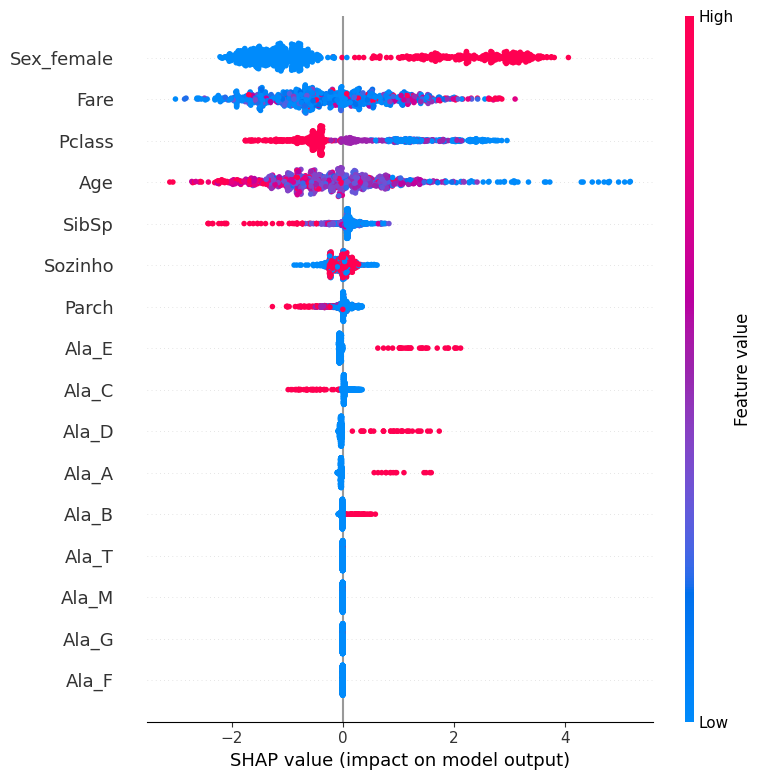

      Variavel  Importancia_SHAP
6   Sex_female          1.647643
4         Fare          0.927809
0       Pclass          0.888149
1          Age          0.881537
2        SibSp          0.213410
5      Sozinho          0.138469
3        Parch          0.132285
11       Ala_E          0.093890
9        Ala_C          0.082830
10       Ala_D          0.064316
7        Ala_A          0.046361
8        Ala_B          0.024922
12       Ala_F          0.000000
13       Ala_G          0.000000
14       Ala_M          0.000000
15       Ala_T          0.000000


In [98]:
modelo_importancia = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_importancia.fit(x,y)

explainer = shap.TreeExplainer(modelo_importancia)
shap_values = explainer.shap_values(x)

shap.summary_plot(shap_values, x, max_display=x.shape[1])

importancia_shap = pd.DataFrame({'Variavel': x.columns, 'Importancia_SHAP': np.abs(shap_values).mean(axis=0)}).sort_values(by='Importancia_SHAP', ascending=False)

print(importancia_shap)

A análise baseada em Importancia_SHAP produziu uma nova ordenação dos atributos mais relevantes para o modelo. O gênero permaneceu como o preditor de maior importância, em concordância com os resultados observados na matriz de correlação. Em contrapartida, houve alteração substancial na posição dos demais atributos mais influentes, com Fare assumindo a segunda posição, seguido por Pclass e Age. Em um nível intermediário de contribuição, destacaram-se Sozinho, Parch e SibSp, enquanto Ala_C, Ala_E, Ala_D, Ala_A e Ala_B apresentaram relevância reduzida. Já Ala_G, Ala_F, Ala_T e Ala_M mostraram impacto nulo sobre as previsões do modelo em ambas as classificações de importância.

Embora as análises por feature_importances_ e SHAP tenham convergido quanto à identificação das variáveis sem contribuição preditiva, houve diferenças expressivas na ordenação dos atributos mais importantes. Considerando que o SHAP oferece uma interpretação mais robusta, ao estimar a contribuição de cada variável com base em princípios da teoria dos jogos, essa abordagem foi adotada como principal referência para a seleção dos atributos.

Ainda assim, a ordem de importância isolada não é suficiente para determinar qual subconjunto de variáveis funciona melhor em conjunto. Por esse motivo, aplicou-se também o SequentialFeatureSelector (SFS), a fim de testar diferentes combinações de atributos e identificar aquela que proporcionasse o melhor equilíbrio entre precisão, recall, f1-score e acurácia.

In [99]:
modelo = XGBClassifier(random_state=42, eval_metric='logloss')
best_f1 = 0
best_atributos = None
best_num = 0
tol = 1e-3

for num in range(1,16):
  sfs = SequentialFeatureSelector(modelo, n_features_to_select=num, direction='forward', scoring='f1_macro', cv=kfold, n_jobs=-1)
  sfs.fit(x, y)

  atributos_sfs = x.columns[sfs.get_support()].tolist()
  print()
  print(f'número de variáveis: {num}')
  print()
  print(atributos_sfs)
  x_sfs = x[atributos_sfs]

  modelo_sfs = XGBClassifier(random_state=42, eval_metric='logloss')
  modelo_sfs.fit(x_sfs, y)
  y_pred_sfs = cross_val_predict(modelo_sfs, x_sfs, y, cv=kfold, method='predict')
  f1_macro_sfs = f1_score(y, y_pred_sfs, average='macro')

  print(f'f1_macro: {f1_macro_sfs:.4f}')
  print(classification_report(y, y_pred_sfs))
  print(confusion_matrix(y, y_pred_sfs))
  print()

  if f1_macro_sfs > best_f1 + tol:
    best_f1 = f1_macro_sfs
    best_atributos = atributos_sfs.copy()
    best_num = num

x_best = x[best_atributos]
print('Melhor quantidade de variáveis:')
print(best_num)
print('Melhores atributos:')
print(best_atributos)
print(f'Melhor f1_macro: {best_f1:.4f}')


número de variáveis: 1

['Sex_female']
f1_macro: 0.7708
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       549
           1       0.74      0.68      0.71       342

    accuracy                           0.79       891
   macro avg       0.78      0.77      0.77       891
weighted avg       0.78      0.79      0.78       891

[[468  81]
 [109 233]]


número de variáveis: 2

['Fare', 'Sex_female']
f1_macro: 0.7855
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       549
           1       0.77      0.69      0.73       342

    accuracy                           0.80       891
   macro avg       0.79      0.78      0.79       891
weighted avg       0.80      0.80      0.80       891

[[478  71]
 [106 236]]


número de variáveis: 3

['Fare', 'Sex_female', 'Ala_A']
f1_macro: 0.7941
              precision    recall  f1-score   support

           0       0.83      0.88      0.85    

In [100]:
x_sfs = dataset['Base de treino'][best_atributos]
modelo_sfs = XGBClassifier(random_state=42, eval_metric='logloss')
modelo_sfs.fit(x_sfs, y)
y_pred_sfs = cross_val_predict(modelo_sfs, x_sfs, y, cv=kfold, method='predict')
print(classification_report(y, y_pred_sfs))
print(confusion_matrix(y, y_pred_sfs))
print()

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       549
           1       0.80      0.75      0.77       342

    accuracy                           0.83       891
   macro avg       0.82      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891

[[483  66]
 [ 86 256]]



Para aplicar o SequentialFeatureSelector, foi avaliado o desempenho do modelo considerando subconjuntos entre 1 e 16 variáveis preditoras. Os melhores resultados foram observados no intervalo de 7 a 11 variáveis, todos com acurácia de 83%. Diante disso, optou-se por selecionar o modelo com 7 variáveis, uma vez que ele apresentou o mesmo desempenho dos demais utilizando a menor quantidade de atributos. As variáveis selecionadas foram: Pclass, Age, Fare, Sex_female, Ala_A, Ala_C e Ala_E.

Em comparação com os modelos anteriores, a seleção da melhor combinação de atributos não promoveu ganho significativo na capacidade preditiva do modelo. Ainda assim, esse desempenho foi alcançado com um número reduzido de variáveis, resultando em um modelo mais parcimonioso, interpretável e com menor complexidade.

O passo seguinte para buscar uma melhora adicional no desempenho do modelo consistiu em testar diferentes combinações de hiperparâmetros. Para isso, optou-se pela utilização da busca aleatória, estratégia que permite explorar de forma mais eficiente um grande espaço de combinações possíveis, com menor custo computacional quando comparada à busca exaustiva.

Os hiperparâmetros avaliados foram: número de estimadores (n_estimators), profundidade máxima das árvores (max_depth), taxa de aprendizado (learning_rate), peso mínimo das instâncias por folha (min_child_weight), proporção de amostras utilizadas em cada árvore (subsample), proporção de variáveis utilizadas na construção de cada árvore (colsample_bytree), ganho mínimo para divisão (gamma), regularização L1 (reg_alpha) e regularização L2 (reg_lambda).

A otimização foi conduzida com foco na métrica f1_macro, já que essa métrica considera de forma equilibrada o desempenho do modelo em ambas as classes, sem favorecer a classe majoritária. Essa escolha se mostra particularmente importante neste problema, uma vez que, nas etapas anteriores, o modelo demonstrou maior facilidade para identificar passageiros não sobreviventes. Dessa forma, ao adotar o f1_macro como critério de seleção, busca-se melhorar principalmente o desempenho preditivo da classe dos sobreviventes, com ênfase no aumento simultâneo de precisão e recall.

Ao final, os resultados obtidos em cada modelo serão comparados entre si, permitindo identificar qual estrutura apresentou melhor resposta ao processo de otimização.

In [101]:
parametros = {'n_estimators':[50, 100, 200, 400, 800, 1600],
              'max_depth':[None, 2, 3, 4, 5, 6, 8, 10],
              'learning_rate':[0.01, 0.02, 0.04, 0.08, 0.1, 0.2, 0.4, 0.8, 1.6],
              'min_child_weight':[1, 2, 4, 6, 8],
              'subsample':[0.7, 0.8, 0.9, 1.0],
              'colsample_bytree':[0.7, 0.8, 0.9, 1.0],
              'gamma':[0, 0.1, 0.2, 0.4, 0.8, 1.0],
              'reg_alpha':[0, 0.01, 0.1, 1],
              'reg_lambda':[1, 2, 4, 6, 8, 10]}

modelos = {'modelo_sfs':(modelo_sfs, x_sfs),
           'modelo_unique':(modelo_unique, x_unique),
           'modelo_red':(modelo_red, x_red),
           'modelo_imp':(modelo_imp, x_imp)}

resultados_busca = {}

for nome, (modelo_atual, x_atual) in modelos.items():
  print()
  print(f'Executando RandomizedSearchCV para {nome}...')
  print()

  busca = RandomizedSearchCV(estimator=modelo_atual, param_distributions=parametros, n_iter=500, scoring='f1_macro', cv=kfold, verbose=1, random_state=42, n_jobs=-1, refit=True)
  busca.fit(x_atual, y)

  melhor_modelo = busca.best_estimator_
  scores = cross_val_score(melhor_modelo, x_atual, y, cv=kfold, scoring='f1_macro')
  resultado = cross_val_predict(melhor_modelo, x_atual, y, cv=kfold, method='predict')

  resultados_busca[nome] = {'best_model':busca.best_estimator_,
                            'best_params':busca.best_params_,
                            'best_score':busca.best_score_}

  print('Melhores parâmetros:')
  print(busca.best_params_)
  print()
  print(f'Melhor score médio: {busca.best_score_:.4f}')
  print()
  print('Classification report:')
  print(classification_report(y, resultado))
  print('Matriz de confusão:')
  print(confusion_matrix(y, resultado))


Executando RandomizedSearchCV para modelo_sfs...

Fitting 10 folds for each of 500 candidates, totalling 5000 fits
Melhores parâmetros:
{'subsample': 0.9, 'reg_lambda': 6, 'reg_alpha': 0, 'n_estimators': 1600, 'min_child_weight': 8, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.9}

Melhor score médio: 0.8355

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       549
           1       0.84      0.75      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.84       891
weighted avg       0.85      0.85      0.85       891

Matriz de confusão:
[[500  49]
 [ 86 256]]

Executando RandomizedSearchCV para modelo_unique...

Fitting 10 folds for each of 500 candidates, totalling 5000 fits
Melhores parâmetros:
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 6, 'max_depth': 10, 'learning_r

In [102]:
resultados_grid = {}

for nome, (modelo_atual, x_atual) in modelos.items():
  print()
  print(f'Executando GridSearchCV para {nome}...')
  print()

  best_params = resultados_busca[nome]['best_params']

  n_estimators = best_params['n_estimators']
  max_depth = best_params['max_depth']
  learning_rate = best_params['learning_rate']
  min_child_weight = best_params['min_child_weight']
  subsample = best_params['subsample']
  colsample_bytree = best_params['colsample_bytree']

  if max_depth is None:
    grid_max_depth = [None, 2, 4, 6]
  else:
    grid_max_depth = sorted(list(set([max(2, max_depth - 1), max_depth, max_depth + 1])))

  grid_parametros = {'n_estimators':[n_estimators - n_estimators // 4, n_estimators, n_estimators + n_estimators // 4],
                     'max_depth':grid_max_depth,
                     'learning_rate':[learning_rate / 2, learning_rate, learning_rate * 2],
                     'min_child_weight':[max(1, min_child_weight - 1), min_child_weight, min_child_weight + 1],
                     'subsample':[subsample, min(1.0, round(subsample + 0.1, 2))],
                     'colsample_bytree':[colsample_bytree, min(1.0, round(colsample_bytree + 0.1, 2))]}


  print('Grade refinada:')
  print(grid_parametros)
  print()

  busca_grid = GridSearchCV(estimator=modelo_atual, param_grid=grid_parametros, scoring='f1_macro', cv=kfold, verbose=1, n_jobs=-1, refit=True)
  busca_grid.fit(x_atual, y)

  resultados_grid[nome] = {'best_model':busca_grid.best_estimator_,
                         'best_params':busca_grid.best_params_,
                         'best_score':busca_grid.best_score_,
                         'x':x_atual}

  print('Melhores parâmetros do grid:')
  print(busca_grid.best_params_)
  print()
  print(f'Melhor score médio do grid: {busca_grid.best_score_:.4f}')


Executando GridSearchCV para modelo_sfs...

Grade refinada:
{'n_estimators': [1200, 1600, 2000], 'max_depth': [2, 3, 4], 'learning_rate': [0.05, 0.1, 0.2], 'min_child_weight': [7, 8, 9], 'subsample': [0.9, 1.0], 'colsample_bytree': [0.9, 1.0]}

Fitting 10 folds for each of 324 candidates, totalling 3240 fits
Melhores parâmetros do grid:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 9, 'n_estimators': 2000, 'subsample': 0.9}

Melhor score médio do grid: 0.8408

Executando GridSearchCV para modelo_unique...

Grade refinada:
{'n_estimators': [75, 100, 125], 'max_depth': [9, 10, 11], 'learning_rate': [0.2, 0.4, 0.8], 'min_child_weight': [5, 6, 7], 'subsample': [0.9, 1.0], 'colsample_bytree': [0.7, 0.8]}

Fitting 10 folds for each of 324 candidates, totalling 3240 fits
Melhores parâmetros do grid:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'min_child_weight': 7, 'n_estimators': 125, 'subsample': 0.9}

Melhor score médio do grid: 0

In [103]:
ranking_modelos = sorted(resultados_grid.items(), key=lambda item: item[1]['best_score'], reverse=True)

for nome, info in ranking_modelos:
  print()
  print(f'Modelo: {nome}')
  print(f'Melhor score do grid: {info["best_score"]:.4f}')
  print('Melhores parâmetros:')
  print(info['best_params'])
  print()

  modelo_atual = info['best_model']
  x_atual = info['x']

  scores = cross_val_score(modelo_atual, x_atual, y, cv=kfold, scoring='f1_macro')

  print(f'Scores: \n{scores}')
  print(f'Média dos scores: {scores.mean():.4f}')
  print(f'Desvio dos scores: {scores.std():.4f}')
  print()

  resultado = cross_val_predict(modelo_atual, x_atual, y, cv=kfold, method='predict')

  print('Classification Report:')
  print(classification_report(y, resultado))
  print('Matriz de confusão:')
  print(confusion_matrix(y, resultado))
  print()
  print('=' * 80)


Modelo: modelo_sfs
Melhor score do grid: 0.8408
Melhores parâmetros:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 9, 'n_estimators': 2000, 'subsample': 0.9}

Scores: 
[0.88526262 0.81294662 0.83143939 0.88944099 0.78800617 0.86671205
 0.82249701 0.80200222 0.86983114 0.84030366]
Média dos scores: 0.8408
Desvio dos scores: 0.0337

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       549
           1       0.84      0.76      0.80       342

    accuracy                           0.85       891
   macro avg       0.85      0.84      0.84       891
weighted avg       0.85      0.85      0.85       891

Matriz de confusão:
[[499  50]
 [ 81 261]]


Modelo: modelo_unique
Melhor score do grid: 0.8404
Melhores parâmetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'min_child_weight': 7, 'n_estimators': 125, 'subsample': 0.9}

Scores: 
[0.89424207 0.82675195 0

Ao final do primeiro ajuste de hiperparâmetros por meio do RandomizedSearch, foi possível elevar a acurácia dos modelos de 83% para 85%. Observa-se que o algoritmo foi capaz de reduzir a diferença entre a precisão das classes de sobreviventes e não sobreviventes, mantendo essa discrepância em no máximo 1%. A taxa de recall também foi melhorada em ambas as classes, porém, a disparidade entre elas se tornou ainda maior do que a observada anteriormente, o que sugere a existência de sobreviventes que não estão sendo identificados adequadamente pelo modelo.

Após o ajuste de hiperparâmetros, o desempenho dos diferentes modelos mostrou-se bastante semelhante, com acurácia idêntica entre eles e apenas pequenas variações nos valores de precisão, recall e f1-score.

Quando o GridSearch foi aplicado sobre os resultados já obtidos, ainda com o objetivo de maximizar o f1_macro, foi possível observar uma melhora adicional no equilíbrio entre as classes. A taxa de recall tornou-se ligeiramente menor para a classe dos não sobreviventes e ligeiramente maior para a classe dos sobreviventes, enquanto a precisão permaneceu bastante próxima da observada anteriormente, embora com uma leve redução na precisão da classe dos sobreviventes. Ainda assim, a acurácia do modelo foi mantida, e o f1-score apresentou um aumento.

Assim como observado na primeira etapa de otimização, os modelos continuaram apresentando desempenhos muito próximos entre si. Dessa forma, para a etapa final deste trabalho, optou-se por submeter todos os modelos desenvolvidos à plataforma Kaggle, a fim de verificar seu comportamento em dados não vistos.

In [104]:
x.head(0)

,Pclass,Age,SibSp,Parch,Fare,Sozinho,Sex_female,Ala_A,Ala_B,Ala_C,Ala_D,Ala_E,Ala_F,Ala_G,Ala_M,Ala_T


In [105]:
dataset['Base de teste'].head(0)

,Pclass,Age,SibSp,Parch,Fare,Name_Civil,Name_Militar,Name_Nobreza,Name_Religioso,Group,...,Ala_D,Ala_E,Ala_F,Ala_G,Ala_M,Ala_T,Ala_U,Embarked_C,Embarked_Q,Embarked_S


#Resultados

In [106]:
for nome, info in ranking_modelos:
  modelo_atual = info['best_model']
  colunas = info['x'].columns.tolist()

  x_teste = dataset['Base de teste'][colunas]
  y_pred = modelo_atual.predict(x_teste)

  resultado = pd.DataFrame({'PassengerId': data_test['PassengerId'], 'Survived': y_pred})
  resultado.to_csv(f'/content/resultado_titanic_{nome}.csv', index=False)

  print(f'Arquivo salvo: /content/resultado_titanic_{nome}.csv')

Arquivo salvo: /content/resultado_titanic_modelo_sfs.csv
Arquivo salvo: /content/resultado_titanic_modelo_unique.csv
Arquivo salvo: /content/resultado_titanic_modelo_red.csv
Arquivo salvo: /content/resultado_titanic_modelo_imp.csv


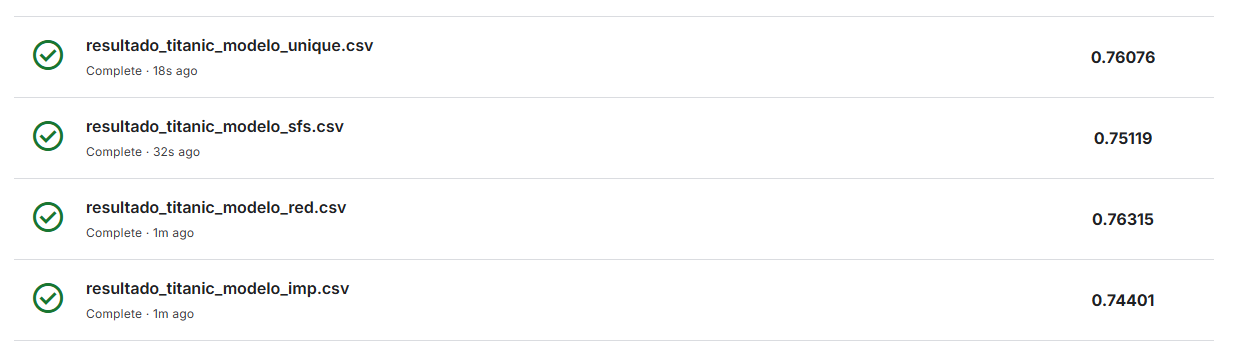

Nesse projeto foi realizada a construção, comparação e refinamento de diferentes versões de modelos preditivos para o problema de sobrevivência no Titanic. Ao longo do processo, foram realizadas etapas de seleção de variáveis, validação cruzada, análise de métricas de classificação, ajuste de hiperparâmetros e, por fim, avaliação externa por meio de submissões na plataforma Kaggle. Esse fluxo tornou possível não apenas melhorar o desempenho interno dos modelos, mas também verificar sua capacidade de generalização em dados não rotulados. Além disso, a submissão dos modelos antes e depois da otimização permitiu analisar com mais clareza o impacto real do ajuste de hiperparâmetros sobre os resultados obtidos.

Os resultados dos modelos não otimizados foram relativamente próximos entre si. O melhor desempenho foi de 74,40% de acerto, obtido pelos modelos completo, unique e reduzido. Em seguida, o modelo de importância e o modelo com SMOTE apresentaram 74,16%, enquanto os piores resultados foram observados no modelo com variáveis padronizadas, com 73,21%, e no modelo construído com Sequential Feature Selector, com 72,97%.

Quando os modelos otimizados foram avaliados, os resultados continuaram próximos. O pior desempenho foi obtido pelo modelo_imp, com 74,40% de acerto. A construção desse modelo envolveu apenas uma seleção simples das variáveis com base em sua contribuição para a predição observada em um modelo completo. Embora essa estratégia tenha permitido reduzir o número de atributos de forma mais direta, o resultado final sugere que esse tipo de seleção não foi suficiente para gerar uma combinação de variáveis capaz de representar melhor o problema, já que o modelo continuou entre os de menor desempenho mesmo após a otimização.

O segundo pior resultado foi obtido pelo modelo_sfs, com 75,12% de acerto. Apesar de esse valor ser superior ao obtido em sua versão não otimizada, a melhora continuou sendo pequena quando comparada às demais opções. Para gerá-lo, foi preciso testar diferentes combinações de variáveis, buscando identificar quais eram capazes de produzir o melhor resultado com a menor quantidade possível de atributos. Na prática, isso tornou a construção do modelo muito mais custosa, sem que o ganho final justificasse esse esforço.

Os outros dois modelos que tiveram seus hiperparâmetros otimizados foram o modelo_unique e o modelo_red, com desempenhos de 76,08% e 76,31%, respectivamente. Esses dois modelos já haviam se destacado em suas versões não otimizadas e, após o ajuste de hiperparâmetros, continuaram apresentando os melhores resultados. Além disso, esses foram os primeiros modelos construídos no trabalho. Para gerá-los, foi necessário analisar as variáveis com maior correlação entre si e selecionar, entre elas, aquelas que produziam o modelo com maior capacidade preditiva, originando o modelo_unique. Em seguida, foram analisadas as importâncias das variáveis utilizadas em sua construção e removidos os atributos com importância igual a zero, o que deu origem ao modelo_red. Essa remoção parece ter reduzido parte do ruído presente nos dados e permitido uma pequena melhora no desempenho final. Embora a diferença entre os dois modelos tenha sido baixa, o modelo_red apresentou o melhor resultado geral do projeto, o que sugere que a retirada de variáveis sem contribuição efetiva foi uma etapa importante para melhorar a qualidade final da predição.

De forma geral, os resultados mostraram que as diferenças de desempenho entre os modelos foram pequenas, tanto antes quanto depois da otimização. Ainda assim, foi possível observar que, para este projeto, técnicas mais simples de seleção de atributos, como a análise de correlação entre variáveis e a remoção de atributos sem importância preditiva, apresentaram resultados melhores do que abordagens mais custosas, como o Sequential Feature Selector. Além disso, a comparação entre os modelos não otimizados e otimizados mostrou que o ajuste de hiperparâmetros não alterou a ordem de desempenho dos modelos já desenvolvidos, apenas ampliou ligeiramente a diferença entre eles.

Portanto, entre as abordagens testadas, o modelo_red foi o que apresentou o melhor desempenho na predição dos sobreviventes ao desastre do Titanic. Sua construção utilizou os atributos gênero, classe, existência de irmãos ou cônjuge a bordo, tarifa, idade, presença de pais ou filhos, informação sobre o passageiro estar viajando sozinho e hospedagem nas alas B, E, C, D ou A. Em conjunto, essas variáveis permitiram estimar a probabilidade de sobrevivência dos passageiros com maior eficiência que as demais abordagens avaliadas.